# PremierPredictor
## Premier League Final Table Predictor · 2024-25

Three models, built from scratch:
1. **Elo ratings** — track team strength after every match  
2. **Poisson regression (Dixon–Coles)** — model goals scored per team  
3. **Monte Carlo simulation** — run the remaining season 10 000 times  


## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import poisson
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dark theme ── swap to 'default' if you prefer light
plt.style.use('dark_background')
sns.set_palette('husl')
ACCENT = '#38bdf8'   # sky blue highlights

OUT = Path('notebook_outputs')
OUT.mkdir(exist_ok=True)

print('Setup complete ✓')

Setup complete ✓


---
## 1 · Load & Inspect Data

The file `E0_2425.csv` is the 2024-25 Premier League season from Football-Data.co.uk.  
Key columns: `HomeTeam`, `AwayTeam`, `FTHG` (full-time home goals), `FTAG` (full-time away goals).

In [2]:
df_raw = pd.read_csv('data/current_season.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

matches = df_raw[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']].copy()
matches = matches.dropna(subset=['FTHG', 'FTAG'])
matches['FTHG'] = matches['FTHG'].astype(int)
matches['FTAG'] = matches['FTAG'].astype(int)
matches = matches.reset_index(drop=True)

teams = sorted(matches['HomeTeam'].unique().tolist())
n_teams = len(teams)
team_idx = {t: i for i, t in enumerate(teams)}

# Merge Understat xG — needed for xG-based Poisson fitting in §3
_xg = pd.read_csv('data/understat_current_season.csv')
_team_map = {
    "Manchester United": "Man United", "Manchester City": "Man City",
    "Newcastle United": "Newcastle", "Nottingham Forest": "Nott'm Forest",
    "Wolverhampton Wanderers": "Wolves",
}
_xg['home_team'] = _xg['home_team'].replace(_team_map)
_xg['away_team'] = _xg['away_team'].replace(_team_map)
_xg['_date'] = pd.to_datetime(_xg['date'])
matches['_date'] = matches['Date']
matches = matches.merge(
    _xg[['_date', 'home_team', 'away_team', 'home_xg', 'away_xg']],
    left_on=['_date', 'HomeTeam', 'AwayTeam'],
    right_on=['_date', 'home_team', 'away_team'],
    how='left'
).drop(columns=['home_team', 'away_team', '_date'])

def compute_form(df, window):
    """Rolling form (pts from last `window` games) known at each match's kick-off."""
    df = df.sort_values('Date').reset_index(drop=True)
    form = {}
    hf, af = [], []
    for _, row in df.iterrows():
        h, a = row.HomeTeam, row.AwayTeam
        if h not in form: form[h] = []
        if a not in form: form[a] = []
        hf.append(sum(form[h][-window:]))
        af.append(sum(form[a][-window:]))
        hg, ag = row.FTHG, row.FTAG
        if hg > ag:    form[h].append(3); form[a].append(0)
        elif hg == ag: form[h].append(1); form[a].append(1)
        else:          form[h].append(0); form[a].append(3)
    return pd.Series(hf, index=df.index), pd.Series(af, index=df.index)

# Default window=5; will be re-optimised in §3
hf, af = compute_form(matches, 5)
matches['home_form5'] = hf
matches['away_form5'] = af

season_label = matches['Season'].iloc[0] if 'Season' in matches.columns else 'current'
xg_n = matches['home_xg'].notna().sum()
print(f'Season : {season_label}  ({matches.Date.min().strftime("%d %b %Y")} → {matches.Date.max().strftime("%d %b %Y")})')
print(f'Teams  : {n_teams}  |  Matches played: {len(matches)}  |  xG matched: {xg_n}/{len(matches)}')
print(f'Avg goals: {matches.FTHG.mean():.2f}H / {matches.FTAG.mean():.2f}A')
matches[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'home_xg', 'away_xg', 'home_form5', 'away_form5']].head()


Season : current  (15 Aug 2025 → 27 Apr 2026)
Teams  : 20  |  Matches played: 339  |  xG matched: 339/339
Avg goals: 1.50H / 1.24A


,Date,HomeTeam,AwayTeam,FTHG,FTAG,home_xg,away_xg,home_form5,away_form5
0,2025-08-15,Liverpool,Bournemouth,4,2,2.330070,1.573030,0,0
1,2025-08-16,Aston Villa,Newcastle,0,0,0.318601,1.400980,0,0
2,2025-08-16,Brighton,Fulham,1,1,1.440080,0.902883,0,0
3,2025-08-16,Sunderland,West Ham,3,0,0.724368,0.558948,0,0
4,2025-08-16,Tottenham,Burnley,3,0,1.978580,0.734138,0,0


### Training — full 2024-25 season

We train the Poisson model on the **complete 2024-25 season** (all 380 matches).  
The fitted parameters capture each team's attack, defence, and home-ground strength  
over the full season, then we use those to simulate 2025-26 cold.

In [3]:
# Train on all played matches in the current season
played = matches.copy()
n_played = len(played)
print(f'Training on {n_played} matches  ({played.Date.min().strftime("%d %b %Y")} → {played.Date.max().strftime("%d %b %Y")})')


Training on 339 matches  (15 Aug 2025 → 27 Apr 2026)


In [4]:
# Current standings — defined here so §9 (Championship) can reference it
def season_table(matches_subset):
    pts = {t: 0 for t in teams}
    gd  = {t: 0 for t in teams}
    for _, row in matches_subset.iterrows():
        h, a, hg, ag = row.HomeTeam, row.AwayTeam, row.FTHG, row.FTAG
        gd[h] += hg - ag; gd[a] += ag - hg
        if hg > ag:    pts[h] += 3
        elif hg == ag: pts[h] += 1; pts[a] += 1
        else:          pts[a] += 3
    return pts, gd

actual_pts, actual_gd = season_table(matches)
actual_df = pd.DataFrame({
    'Team'     : teams,
    'ActualPts': [actual_pts[t] for t in teams],
    'ActualGD' : [actual_gd[t]  for t in teams],
})
actual_df = actual_df.sort_values(['ActualPts', 'ActualGD'], ascending=False).reset_index(drop=True)
actual_df.index += 1

n_remaining = 380 - len(matches)
print(f'Current standings — {len(matches)} matches played, {n_remaining} remaining:')
print(actual_df[['Team','ActualPts','ActualGD']].to_string())


Current standings — 339 matches played, 41 remaining:
              Team  ActualPts  ActualGD
1          Arsenal         73        38
2         Man City         70        37
3       Man United         61        14
4        Liverpool         58        13
5      Aston Villa         58         5
6         Brighton         50         9
7      Bournemouth         49         0
8          Chelsea         48         8
9        Brentford         48         3
10          Fulham         48        -2
11         Everton         47         0
12      Sunderland         46        -9
13  Crystal Palace         43        -3
14       Newcastle         42        -4
15           Leeds         40        -7
16   Nott'm Forest         39        -4
17        West Ham         36       -16
18       Tottenham         34       -10
19         Burnley         20       -34
20          Wolves         17       -38


---
## 2 · Elo Ratings

### What is Elo?

Elo is a zero-sum relative rating system originally designed for chess by Arpad Elo in the 1950s. Every team starts at 1500, and after each match points transfer from the loser to the winner. The key insight: **how many points transfer depends on how surprising the result was.** Beating a much stronger team earns you more than beating a weaker one.

### The expected score formula

$$E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}$$

- $E_A$ is the probability team A wins, on a 0–1 scale (0.5 = evenly matched)
- The **400** controls the steepness of the curve. A 400-point rating gap gives the stronger side roughly a 90% win probability. A 200-point gap → about 76%.
- When ratings are equal, $E_A = 0.5$ exactly — coin flip.

### The update formula

$$R_A' = R_A + K \cdot (S_A - E_A)$$

- $S_A$ = actual outcome: **1** for win · **0.5** for draw · **0** for loss
- $K = 32$ = the learning rate. Higher K means ratings react faster to each result. Chess grandmasters use K=10 (stable, lots of games); we use 32 which lets ratings adjust meaningfully over a 38-game season.
- $(S_A - E_A)$ is the "surprise" term. If A was expected to win with 80% probability and did win, the surprise is only +0.2 and the rating barely moves. If A pulled off an upset (expected 20%, got 1), the surprise is +0.8 and both teams move significantly.

### Home advantage

We add **100 Elo points** to the home team *before* computing the expected score. This doesn't change the home team's stored rating — it's just a thumb on the scale for the calculation. A 100-point bonus gives the home team roughly a 64% expected score against an equally-rated opponent, which matches historical Premier League home win rates.

### Limitation worth knowing

Elo only uses the *result* — win, draw, or loss. A 5-0 and a 1-0 update ratings identically. The model doesn't know the goals happened; it just knows who won. This is why we need the Poisson model in §3, which uses actual goal counts (and xG) to get a richer signal.

In [5]:
K         = 32
HOME_BONUS = 100   # Elo points added to home team before computing expected score
ELO_START  = 1500

def expected(ra, rb):
    return 1 / (1 + 10 ** ((rb - ra) / 400))

def elo_update(r_home, r_away, hg, ag):
    e = expected(r_home + HOME_BONUS, r_away)
    s = 1.0 if hg > ag else (0.5 if hg == ag else 0.0)
    return r_home + K * (s - e), r_away + K * ((1 - s) - (1 - e))

# Run Elo over all 380 matches (full-season view)
elo = {t: ELO_START for t in teams}
history = {t: [ELO_START] for t in teams}

for _, row in matches.iterrows():
    h, a = row.HomeTeam, row.AwayTeam
    elo[h], elo[a] = elo_update(elo[h], elo[a], row.FTHG, row.FTAG)
    for t in teams:
        history[t].append(elo[t])

# Elo at the training cut-off (for use in Monte Carlo later)
elo_split = {t: ELO_START for t in teams}
for _, row in played.iterrows():
    h, a = row.HomeTeam, row.AwayTeam
    elo_split[h], elo_split[a] = elo_update(elo_split[h], elo_split[a], row.FTHG, row.FTAG)

elo_df = (pd.DataFrame({'Team': teams, 'Elo': [elo_split[t] for t in teams]})
            .sort_values('Elo', ascending=False)
            .reset_index(drop=True))
elo_df.index += 1
print('Elo ratings at GW19 (training cut-off):')
elo_df

Elo ratings at GW19 (training cut-off):


,Team,Elo
1,Man City,1655.513264
2,Arsenal,1636.956824
3,Man United,1596.306158
4,Liverpool,1555.574280
5,Bournemouth,1553.545563
6,Aston Villa,1538.679496
7,Brighton,1537.856060
8,Brentford,1506.699686
9,Leeds,1505.892630
10,Fulham,1504.269366


### Elo trajectories — top 8 teams (full season)

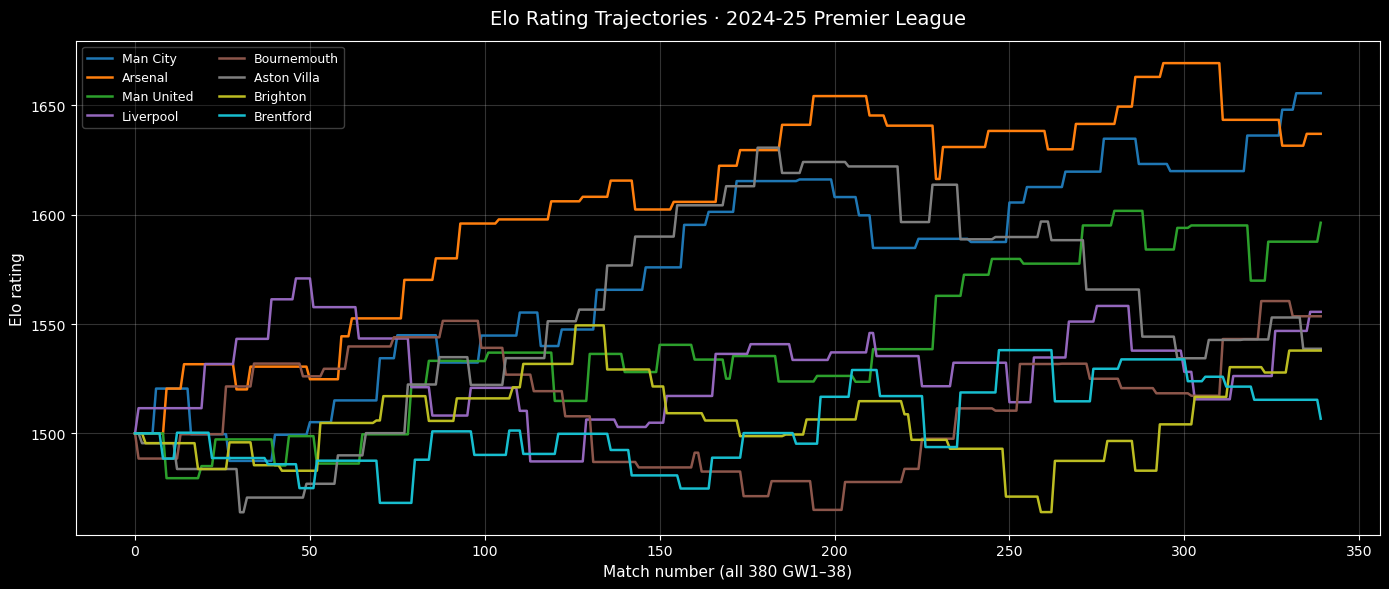

In [6]:
top8 = elo_df.head(8)['Team'].tolist()
x = range(len(matches) + 1)

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 8))
for team, c in zip(top8, colors):
    ax.plot(x, history[team], lw=1.8, label=team, color=c)

ax.set_xlabel('Match number (all 380 GW1–38)', fontsize=11)
ax.set_ylabel('Elo rating', fontsize=11)
ax.set_title('Elo Rating Trajectories · 2024-25 Premier League', fontsize=14, pad=12)
ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUT / 'elo_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3 · Dixon–Coles Poisson Regression (fitted on xG)

### Why Poisson?

Goals are discrete counts (0, 1, 2, …) that occur randomly over 90 minutes. The **Poisson distribution** is the standard model for this kind of count data — it describes how many events happen in a fixed interval given a constant average rate λ (lambda). For example, if a team's λ = 1.6, the distribution tells us: roughly 20% chance of 0 goals, 32% chance of 1, 26% chance of 2, and so on.

The model assumes each team has an inherent *attack* quality (how many goals above/below average they score) and a *defence* quality (how many they concede). These combine to produce λ for each fixture.

### The Dixon–Coles model

Dixon and Coles (1997) gave the first principled statistical football model. Each team gets two parameters:

$$\lambda_{\text{home}} = \exp(\text{attack}_H + \text{defence}_A + \text{home\_adv}_H + \text{form\_coeff} \times \Delta\text{form})$$
$$\lambda_{\text{away}} = \exp(\text{attack}_A + \text{defence}_H - \text{form\_coeff} \times \Delta\text{form})$$

**Why exp()?** The parameters are on a log scale. This guarantees λ is always positive (you can't have negative expected goals). An attack parameter of +0.3 means the team scores $e^{0.3} \approx 1.35\times$ the baseline. A defence parameter of −0.4 means the team concedes $e^{-0.4} \approx 0.67\times$ as many goals against them.

**Identifiability:** With n attack and n defence parameters, the model is underdetermined — you could add 1 to every attack and subtract 1 from every defence and get identical predictions. We fix one team's attack (Arsenal, alphabetically first) to 0 to anchor the scale. All other teams' attacks are relative to Arsenal.

The parameters are found by maximising the **log-likelihood** — the sum of log-probabilities of each observed scoreline under the model. We use `scipy.optimize.minimize` with the L-BFGS-B algorithm, a gradient-based optimiser suited to problems with many parameters and optional bounds.

### Why xG instead of actual goals?

Actual goals are noisy. A deflected 40-yard long shot and a clinical one-on-one both count as 1 goal, but they're wildly different in terms of team quality. **xG (expected goals)** is a shot-quality-weighted score: each shot is given a probability of going in based on its location, angle, and type. A team that creates consistent high-quality chances will have high xG regardless of whether the ball went in that particular game.

Fitting on xG gives the model a cleaner signal of true team strength — especially important early in a season when 19 games worth of actual goals is easily distorted by a few lucky or unlucky results.

*Note on implementation:* Standard Poisson log-PMF requires integer k. Since xG values are continuous (e.g., 1.34 expected goals), we use the generalised form via the log-Gamma function: $\ell(k, \lambda) = k \ln\lambda - \lambda - \ln\Gamma(k+1)$. This is mathematically equivalent for integers but valid for any positive real k.

### Enhancements beyond the basic model

**Time decay (ξ — xi):**  
An August match shouldn't count the same as a May match — teams evolve across the season. Each match's contribution to the log-likelihood is multiplied by a weight $w = e^{-\xi \cdot d}$, where $d$ is the number of days before the training cutoff. Recent matches get weight ≈ 1; matches from many months ago get downweighted. We bound ξ ≤ 0.015, giving a half-life of at least 46 days — the classic Dixon-Coles value is 0.0065 (~107-day half-life). Tighter bounds prevent the optimiser from concentrating everything on the last week of results.

**Per-team home advantage:**  
Rather than one global home boost, each team gets its own `home_adv` parameter. Anfield's atmosphere measurably shifts results differently from Goodison Park — this lets the model capture that.

**Form (form\_coeff + adaptive window):**  
$\Delta\text{form}$ is the difference in rolling *N*-game points between home and away at kick-off time. A team on a winning streak gets a small λ boost over one that hasn't won recently. The coefficient is bounded to ±0.05 so form nudges but doesn't override structural quality.

The window length *N* is not fixed — we try *N* ∈ {3, 5, 8} games and pick the value that minimises negative log-likelihood on the training data. This lets the model discover whether the current season responds more to very recent form (3 games) or a longer trend (8 games).

**Low-score correction (ρ — rho):**  
Pure independent Poisson underpredicts 0-0 and 1-1 results. The reason: the two teams' scores aren't truly independent — a bad attacking day for one side tends to coincide with a strong defensive performance by the other. Dixon and Coles introduced a correction factor τ that multiplies the joint probability for low-score outcomes:

$$\tau(H, A) = \begin{cases} 1 - \lambda_H \lambda_A \rho & H=0, A=0 \\ 1 + \lambda_A \rho & H=1, A=0 \\ 1 + \lambda_H \rho & H=0, A=1 \\ 1 - \rho & H=1, A=1 \\ 1 & \text{otherwise} \end{cases}$$

ρ > 0 means more 0-0s and 1-1s than Poisson predicts. It's fitted separately on actual integer goals (not xG) since it corrects for discrete scoreline clustering, not shot quality.

In [7]:
from scipy.special import gammaln
from scipy.optimize import minimize, minimize_scalar
from scipy.stats import poisson as _scipy_poisson

# ─── Parameter layout (3n + 2 total) ─────────────────────────────────────────
#  raw[0 .. n-2]     attack[1..n-1]       (attack[0] = Arsenal, fixed at 0)
#  raw[n-1 .. 2n-2]  defence[0..n-1]
#  raw[2n .. 3n-1]   home_adv[0..n-1]     per-team (e.g. Anfield > Goodison)
#  raw[3n]           xi    — time-decay rate (≥ 0); weight = exp(-xi * days)
#  raw[3n+1]         form_coeff — how much form-difference shifts λ

def build_params(raw, teams):
    n = len(teams)
    attack     = {teams[0]: 0.0}
    attack.update({teams[i]: raw[i - 1] for i in range(1, n)})
    defence    = {teams[i]: raw[n - 1 + i] for i in range(n)}
    home_adv   = {teams[i]: raw[2 * n + i] for i in range(n)}
    xi         = float(np.clip(raw[3 * n], 0.0, None))
    form_coeff = float(raw[3 * n + 1])
    return attack, defence, home_adv, xi, form_coeff

def poisson_logpmf_continuous(k, lam):
    # Generalised Poisson log-PMF valid for non-integer k (uses log-Gamma).
    # scipy.stats.poisson.logpmf returns -inf for non-integer k.
    return k * np.log(lam) - lam - gammaln(k + 1)

def neg_log_lik(raw, df, teams, T):
    attack, defence, home_adv, xi, form_coeff = build_params(raw, teams)

    days      = (T - df['Date']).dt.days.values.astype(float)
    weights   = np.exp(-xi * days)
    form_diff = (df['home_form5'] - df['away_form5']).values

    lam_h = np.array([
        np.exp(attack[h] + defence[a] + home_adv[h] + form_coeff * fd)
        for h, a, fd in zip(df['HomeTeam'], df['AwayTeam'], form_diff)
    ])
    lam_a = np.array([
        np.exp(attack[a] + defence[h] - form_coeff * fd)
        for h, a, fd in zip(df['HomeTeam'], df['AwayTeam'], form_diff)
    ])

    xg_h = df['home_xg'].values
    xg_a = df['away_xg'].values
    ll_h = xg_h * np.log(lam_h) - lam_h - gammaln(xg_h + 1)
    ll_a = xg_a * np.log(lam_a) - lam_a - gammaln(xg_a + 1)
    return -(weights * (ll_h + ll_a)).sum()

played_xg = played.dropna(subset=['home_xg', 'away_xg']).copy()
T = played_xg['Date'].max()
print(f'Training: {len(played_xg)} matches  |  cutoff {T.strftime("%d %b %Y")}')

n  = n_teams
x0 = np.zeros(3 * n + 2)
x0[3 * n] = 0.003   # xi init: mild decay  (~½-life 230 days)

# Bound xi: optimising in-sample pushes it to ∞ (overfit on last few matches).
# Max 0.015 → ½-life ≥ 46 days; classic Dixon-Coles value is 0.0065 (~107 days).
# Bound form_coeff: a 10-pt form gap should shift λ by at most e^0.5 ≈ 1.65×.
bounds = [(None, None)] * (3 * n) + [(0.0, 0.015), (-0.05, 0.05)]

# ─── Form-window grid search ──────────────────────────────────────────────────
# Try rolling windows of 3, 5, 8 games; pick the one that minimises neg-log-lik.
# Quick fit (maxiter=400) just to rank windows — final fit runs below with full iters.
print('\nGrid-searching form window (3 / 5 / 8 games)…')
best_window, best_nll = 5, np.inf
for w in [3, 5, 8]:
    tmp = played_xg.copy()
    hf, af = compute_form(tmp, w)
    tmp['home_form5'] = hf.values
    tmp['away_form5'] = af.values
    r = minimize(neg_log_lik, x0, args=(tmp, teams, T),
                 method='L-BFGS-B', bounds=bounds,
                 options={'maxiter': 400, 'ftol': 1e-8})
    print(f'  window={w:2d} games: neg-LL = {r.fun:.2f}')
    if r.fun < best_nll:
        best_nll, best_window = r.fun, w

print(f'Best form window: {best_window} games  → updating played_xg')
hf, af = compute_form(played_xg, best_window)
played_xg = played_xg.copy()
played_xg['home_form5'] = hf.values
played_xg['away_form5'] = af.values

# ─── Full Poisson fit ─────────────────────────────────────────────────────────
print(f'\nFitting Poisson model on xG  (form window={best_window} · time-decay ξ · per-team home_adv) …')
result = minimize(
    neg_log_lik, x0,
    args=(played_xg, teams, T),
    method='L-BFGS-B', bounds=bounds,
    options={'maxiter': 2000, 'ftol': 1e-12}
)
print(f'Converged: {result.success}  |  neg-log-likelihood: {result.fun:.2f}')

attack, defence, home_adv, xi, form_coeff = build_params(result.x, teams)
hl = f'½-life ≈ {np.log(2)/xi:.0f} days' if xi > 1e-8 else 'no decay'
print(f'\nTime-decay ξ    : {xi:.5f}  ({hl})')
print(f'Form window     : {best_window} games  (selected by grid search)')
print(f'Form coefficient: {form_coeff:.4f}  (per pt of form{best_window} difference)')
top_ha = sorted(home_adv.items(), key=lambda x: -x[1])
print(f'Strongest home grounds: {[(t, round(v,3)) for t,v in top_ha[:5]]}')

# ─── Low-score correction ρ (Dixon-Coles) ────────────────────────────────────
# Fitting on xG captures team quality; ρ separately calibrates the known bias
# in integer goal outcomes (0-0 and 1-1 occur more than independent Poisson predicts).
# We fit ρ on actual goals using the already-estimated lambdas.

def dc_tau(hg, ag, lh, la, rho):
    if   hg == 0 and ag == 0: return 1.0 - lh * la * rho
    elif hg == 1 and ag == 0: return 1.0 + la * rho
    elif hg == 0 and ag == 1: return 1.0 + lh * rho
    elif hg == 1 and ag == 1: return 1.0 - rho
    return 1.0

def rho_neg_ll(rho, df, attack, defence, home_adv, form_coeff):
    ll = 0.0
    for _, row in df.iterrows():
        h, a = row.HomeTeam, row.AwayTeam
        fd  = row.home_form5 - row.away_form5
        lh  = np.exp(attack[h] + defence[a] + home_adv[h] + form_coeff * fd)
        la  = np.exp(attack[a] + defence[h] - form_coeff * fd)
        tau = dc_tau(int(row.FTHG), int(row.FTAG), lh, la, rho)
        if tau <= 0: return 1e9
        ll += np.log(tau) + _scipy_poisson.logpmf(int(row.FTHG), lh) + _scipy_poisson.logpmf(int(row.FTAG), la)
    return -ll

rho_res = minimize_scalar(rho_neg_ll, bounds=(-0.2, 0.2), method='bounded',
                           args=(played_xg, attack, defence, home_adv, form_coeff))
rho = rho_res.x
print(f'\nLow-score ρ     : {rho:.4f}')
print(f'  τ(0-0) at λ=(1.5,1.4): {dc_tau(0,0,1.5,1.4,rho):.3f}  ({"more" if dc_tau(0,0,1.5,1.4,rho)>1 else "fewer"} 0-0s than Poisson)')
print(f'  τ(1-1) at λ=(1.5,1.4): {dc_tau(1,1,1.5,1.4,rho):.3f}')


Training: 339 matches  |  cutoff 27 Apr 2026

Grid-searching form window (3 / 5 / 8 games)…
  window= 3 games: neg-LL = 210.50
  window= 5 games: neg-LL = 210.54
  window= 8 games: neg-LL = 210.52
Best form window: 3 games  → updating played_xg

Fitting Poisson model on xG  (form window=3 · time-decay ξ · per-team home_adv) …
Converged: False  |  neg-log-likelihood: 210.50

Time-decay ξ    : 0.01500  (½-life ≈ 46 days)
Form window     : 3 games  (selected by grid search)
Form coefficient: 0.0060  (per pt of form3 difference)
Strongest home grounds: [('Brentford', 0.588), ('Aston Villa', 0.537), ('Newcastle', 0.48), ('Brighton', 0.472), ('Tottenham', 0.468)]

Low-score ρ     : -0.1130
  τ(0-0) at λ=(1.5,1.4): 1.237  (more 0-0s than Poisson)
  τ(1-1) at λ=(1.5,1.4): 1.113


In [8]:
params_df = pd.DataFrame({
    'Team'    : teams,
    'Attack'  : [attack[t]   for t in teams],
    'Defence' : [defence[t]  for t in teams],
    'HomeAdv' : [home_adv[t] for t in teams],
})
params_df['AttackRank']  = params_df['Attack'].rank(ascending=False).astype(int)
params_df['DefenceRank'] = params_df['Defence'].rank(ascending=True).astype(int)
params_df['HomeAdvRank'] = params_df['HomeAdv'].rank(ascending=False).astype(int)
params_df = params_df.sort_values('Attack', ascending=False).reset_index(drop=True)
params_df.index += 1
print('Model parameters (sorted by attack strength):')
params_df.round(3)

Model parameters (sorted by attack strength):


,Team,Attack,Defence,HomeAdv,AttackRank,DefenceRank,HomeAdvRank
1,Man City,0.015,0.537,0.134,1,3,10
2,Arsenal,0.000,0.345,-0.191,2,1,20
3,Bournemouth,-0.030,0.810,-0.054,3,13,17
4,Chelsea,-0.094,0.720,-0.008,4,11,15
5,Liverpool,-0.217,0.821,0.063,5,15,14
6,Leeds,-0.247,0.597,0.115,6,4,12
7,Crystal Palace,-0.337,0.713,0.089,7,10,13
8,Everton,-0.365,0.690,-0.151,8,7,19
9,Sunderland,-0.461,0.865,-0.137,9,17,18
10,Man United,-0.467,0.649,0.379,10,5,7


In [9]:
import itertools

# Teams come directly from the current season data — no cold priors needed
teams_2526  = sorted(matches['HomeTeam'].unique().tolist())
n_2526      = len(teams_2526)
tidx_2526   = {t: i for i, t in enumerate(teams_2526)}

# Current actual points and GD (seed for MC simulation)
actual_pts_arr = np.array([actual_pts[t] for t in teams_2526], dtype=int)
actual_gd_arr  = np.array([actual_gd[t]  for t in teams_2526], dtype=int)

# Remaining fixtures = all 380 permutations minus already-played home/away pairs
played_pairs   = set(zip(played['HomeTeam'], played['AwayTeam']))
all_pairs      = list(itertools.permutations(teams_2526, 2))
remaining      = [(h, a) for h, a in all_pairs if (h, a) not in played_pairs]

print(f'2025-26 Premier League  ({n_2526} teams)')
print(f'  Played   : {len(played_pairs)} fixtures')
print(f'  Remaining: {len(remaining)} fixtures to simulate')
print(f'  Total    : {len(all_pairs)} (should be 380)')


2025-26 Premier League  (20 teams)
  Played   : 339 fixtures
  Remaining: 41 fixtures to simulate
  Total    : 380 (should be 380)


### Attack vs Defence scatter — model parameters

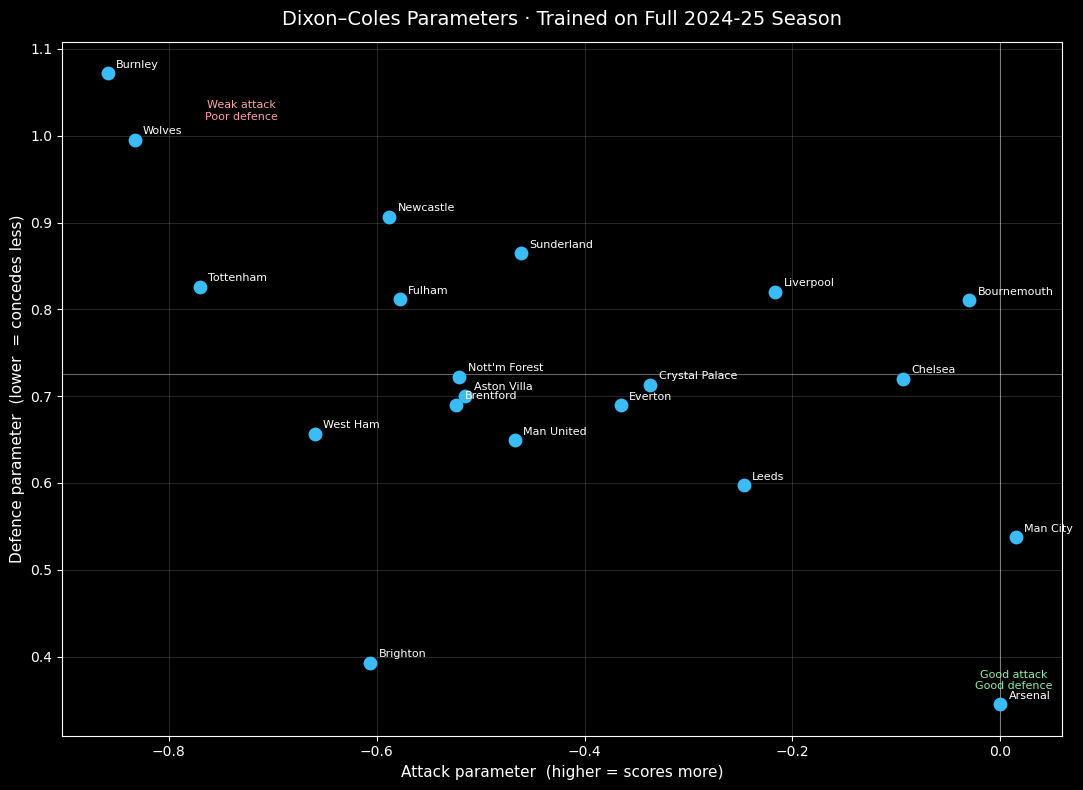

In [10]:
fig, ax = plt.subplots(figsize=(11, 8))

xs = [attack[t]  for t in teams]
ys = [defence[t] for t in teams]

ax.scatter(xs, ys, s=80, color=ACCENT, zorder=3)
for t, x_, y_ in zip(teams, xs, ys):
    ax.annotate(t, (x_, y_), textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.axvline(0, color='white', lw=0.8, alpha=0.4)
ax.axhline(np.mean(ys), color='white', lw=0.8, alpha=0.4)
ax.set_xlabel('Attack parameter  (higher = scores more)',  fontsize=11)
ax.set_ylabel('Defence parameter  (lower  = concedes less)', fontsize=11)
ax.set_title('Dixon–Coles Parameters · Trained on Full 2024-25 Season', fontsize=14, pad=12)
ax.grid(True, alpha=0.15)

ax.text(max(xs)*0.85, min(ys)*1.05, 'Good attack\nGood defence', color='#86efac', fontsize=8, ha='center')
ax.text(min(xs)*0.85, max(ys)*0.95, 'Weak attack\nPoor defence',  color='#fca5a5', fontsize=8, ha='center')

plt.tight_layout()
plt.savefig(OUT / 'attack_defence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Supporting Analysis

The sections below explore the data behind the model — xG trends, player contributions,
squad depth, Championship context, and a bookmaker calibration check.
These do not change the prediction; they provide context and validation.

---
## 6 · Multi-Season xG Analysis

We now have 6 seasons of data (2019-25) enriched with Understat xG.  
xG = *expected goals* — the probability a shot becomes a goal based on location, angle, and type.  
A team that scores **more** than their xG is overperforming (lucky or clinical); **less** means they're wasting chances.

In [11]:
from pathlib import Path

DATA = Path('data')
matches_full = pd.read_csv(DATA / 'matches_full.csv', parse_dates=['Date'])

# Keep only rows where xG was matched
mxg = matches_full.dropna(subset=['home_xg', 'away_xg']).copy()
mxg['home_xg'] = mxg['home_xg'].astype(float)
mxg['away_xg'] = mxg['away_xg'].astype(float)
mxg['FTHG']    = mxg['FTHG'].astype(int)
mxg['FTAG']    = mxg['FTAG'].astype(int)

print(f"Matches with xG: {len(mxg)} across {mxg['Season'].nunique()} seasons")
print(f"Date range: {mxg.Date.min().date()} → {mxg.Date.max().date()}")
mxg[['Date','Season','HomeTeam','AwayTeam','FTHG','FTAG','home_xg','away_xg']].head()

Matches with xG: 2242 across 6 seasons
Date range: 2019-08-09 → 2025-05-25


,Date,Season,HomeTeam,AwayTeam,FTHG,FTAG,home_xg,away_xg
0,2019-08-09,2019-20,Liverpool,Norwich,4,1,2.234560,0.842407
1,2019-08-10,2019-20,West Ham,Man City,0,5,1.200300,3.183770
2,2019-08-10,2019-20,Bournemouth,Sheffield United,1,1,1.340990,1.598640
3,2019-08-10,2019-20,Burnley,Southampton,3,0,0.909241,1.087520
4,2019-08-10,2019-20,Crystal Palace,Everton,0,0,0.871590,1.224600


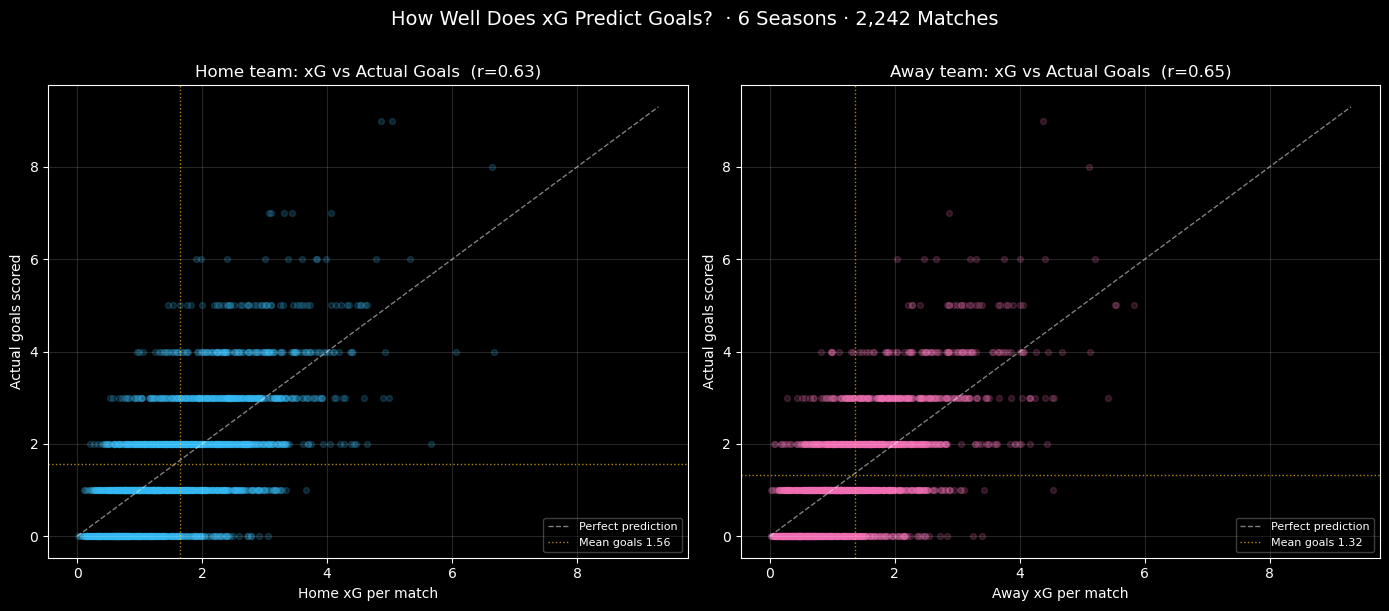

xG correlates strongly with goals — but there is variance. That variance is luck (or clinical finishing).


In [12]:
# xG vs Actual Goals scatter — how well does xG predict scoring?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, side, xg_col, goals_col, color, label in [
    (axes[0], 'Home', 'home_xg', 'FTHG', '#38bdf8', 'Home'),
    (axes[1], 'Away', 'away_xg', 'FTAG', '#f472b6', 'Away'),
]:
    xg   = mxg[xg_col].values
    gls  = mxg[goals_col].values
    ax.scatter(xg, gls, alpha=0.18, s=18, color=color, rasterized=True)

    # Ideal line: xG = actual goals
    lim = max(xg.max(), gls.max()) + 0.3
    ax.plot([0, lim], [0, lim], 'w--', lw=1, alpha=0.5, label='Perfect prediction')

    # Mean line
    ax.axhline(gls.mean(), color='#fbbf24', lw=1, ls=':', alpha=0.7, label=f'Mean goals {gls.mean():.2f}')
    ax.axvline(xg.mean(),  color='#fbbf24', lw=1, ls=':', alpha=0.7)

    corr = np.corrcoef(xg, gls)[0, 1]
    ax.set_title(f'{label} team: xG vs Actual Goals  (r={corr:.2f})', fontsize=12)
    ax.set_xlabel(f'{label} xG per match', fontsize=10)
    ax.set_ylabel('Actual goals scored', fontsize=10)
    ax.legend(fontsize=8, framealpha=0.3)
    ax.grid(True, alpha=0.15)

fig.suptitle('How Well Does xG Predict Goals?  · 6 Seasons · 2,242 Matches', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print('xG correlates strongly with goals — but there is variance. That variance is luck (or clinical finishing).')

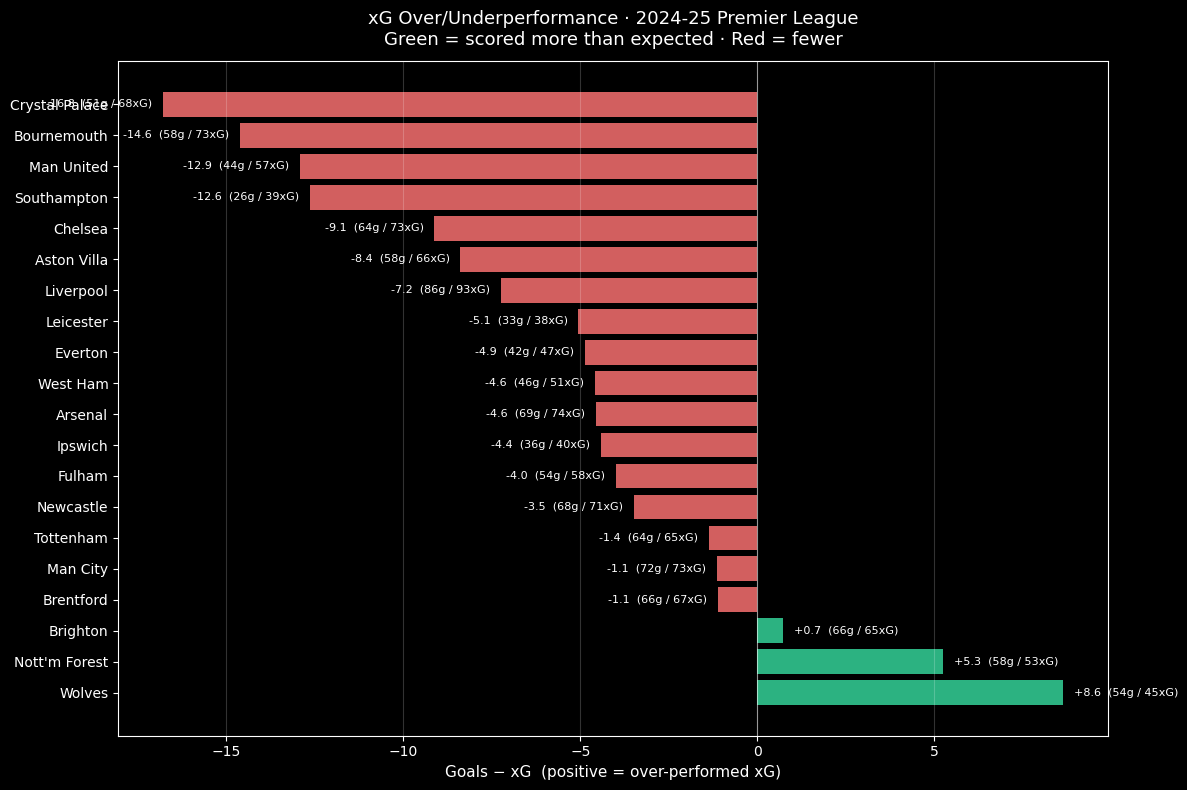


Top over-performers (clinical or lucky):
         team  total_goals  total_xg   xg_diff
       Wolves           54 45.370551  8.629449
Nott'm Forest           58 52.749253  5.250747
     Brighton           66 65.276870  0.723130
    Brentford           66 67.119797 -1.119797
     Man City           72 73.148430 -1.148430

Biggest under-performers (wasteful or unlucky):
          team  total_goals  total_xg    xg_diff
       Chelsea           64 73.117289  -9.117289
   Southampton           26 38.631216 -12.631216
    Man United           44 56.911310 -12.911310
   Bournemouth           58 72.620869 -14.620869
Crystal Palace           51 67.780770 -16.780770


In [13]:
# Per-team xG overperformance (goals − xG) for 2024-25
# Positive = scored more than model expected (clinical / lucky)
# Negative = scored less (wasteful / unlucky)

season_24 = mxg[mxg['Season'] == '2024-25'].copy()

# Stack home and away rows into one long-form df per team
home_rows = season_24[['HomeTeam','FTHG','home_xg']].rename(columns={'HomeTeam':'team','FTHG':'goals','home_xg':'xg'})
away_rows = season_24[['AwayTeam','FTAG','away_xg']].rename(columns={'AwayTeam':'team','FTAG':'goals','away_xg':'xg'})
team_xg = pd.concat([home_rows, away_rows]).groupby('team').agg(
    total_goals=('goals','sum'),
    total_xg   =('xg',   'sum'),
    matches    =('goals','count'),
).reset_index()
team_xg['xg_diff']   = team_xg['total_goals'] - team_xg['total_xg']
team_xg['goals_p90'] = (team_xg['total_goals'] / team_xg['matches']).round(2)
team_xg['xg_p90']    = (team_xg['total_xg']    / team_xg['matches']).round(2)
team_xg = team_xg.sort_values('xg_diff', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#34d399' if x >= 0 else '#f87171' for x in team_xg['xg_diff']]
bars = ax.barh(team_xg['team'], team_xg['xg_diff'], color=colors, alpha=0.85)
ax.axvline(0, color='white', lw=0.8, alpha=0.5)

for bar, row in zip(bars, team_xg.itertuples()):
    ax.text(bar.get_width() + (0.3 if row.xg_diff >= 0 else -0.3),
            bar.get_y() + bar.get_height()/2,
            f'{row.xg_diff:+.1f}  ({row.total_goals}g / {row.total_xg:.0f}xG)',
            va='center', ha='left' if row.xg_diff >= 0 else 'right', fontsize=8)

ax.set_xlabel('Goals − xG  (positive = over-performed xG)', fontsize=11)
ax.set_title('xG Over/Underperformance · 2024-25 Premier League\nGreen = scored more than expected · Red = fewer', fontsize=13, pad=12)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

print('\nTop over-performers (clinical or lucky):')
print(team_xg[['team','total_goals','total_xg','xg_diff']].head(5).to_string(index=False))
print('\nBiggest under-performers (wasteful or unlucky):')
print(team_xg[['team','total_goals','total_xg','xg_diff']].tail(5).to_string(index=False))

---
## 7 · Player Impact

Player data from Understat covers 1,343 unique players across 6 seasons.  
Key metrics:
- **xG** — expected goals from shots taken (how many goals the model thinks they *should* have scored)  
- **xA** — expected assists (xG of chances they created for teammates)  
- **xGChain** — xG of every move the player was directly involved in (total threat contribution)  
- **xGBuildup** — xG from build-up play only (excludes shots and key passes — measures off-ball work)

In [14]:
impact = pd.read_csv(DATA / 'player_impact.csv')

# Focus on players with meaningful minutes (at least one full season equivalent)
qualified = impact[impact['minutes'] >= 3000].copy()
print(f"Players with 3000+ career minutes: {len(qualified)}")
qualified[['player','teams','seasons','games','minutes','goals','xg','xg_p90','xa_p90','xgchain_p90']].head(15)

Players with 3000+ career minutes: 496


,player,teams,seasons,games,minutes,goals,xg,xg_p90,xa_p90,xgchain_p90
0,Mohamed Salah,Liverpool,6,214,18001,130,138.266067,0.691,0.310,1.027
1,Erling Haaland,Manchester City,3,97,8133,85,88.369989,0.978,0.157,0.941
2,Ollie Watkins,Aston Villa,5,184,15366,75,83.161690,0.487,0.138,0.641
3,Harry Kane,Tottenham,4,139,12335,88,79.221437,0.578,0.205,0.721
4,Chris Wood,"Burnley, Burnley,Newcastle United, Newcastle U...",6,191,13590,68,70.829980,0.469,0.068,0.455
5,Dominic Calvert-Lewin,Everton,6,161,11870,46,69.248589,0.525,0.077,0.534
6,Son Heung-Min,Tottenham,6,203,16745,85,68.200421,0.367,0.284,0.729
7,Jamie Vardy,Leicester,5,166,12411,65,67.701959,0.491,0.134,0.542
8,Gabriel Jesus,"Arsenal, Manchester City",6,161,10144,49,67.660008,0.600,0.196,0.954
9,Raheem Sterling,"Arsenal, Chelsea, Manchester City",6,170,11728,57,64.578452,0.496,0.224,0.886


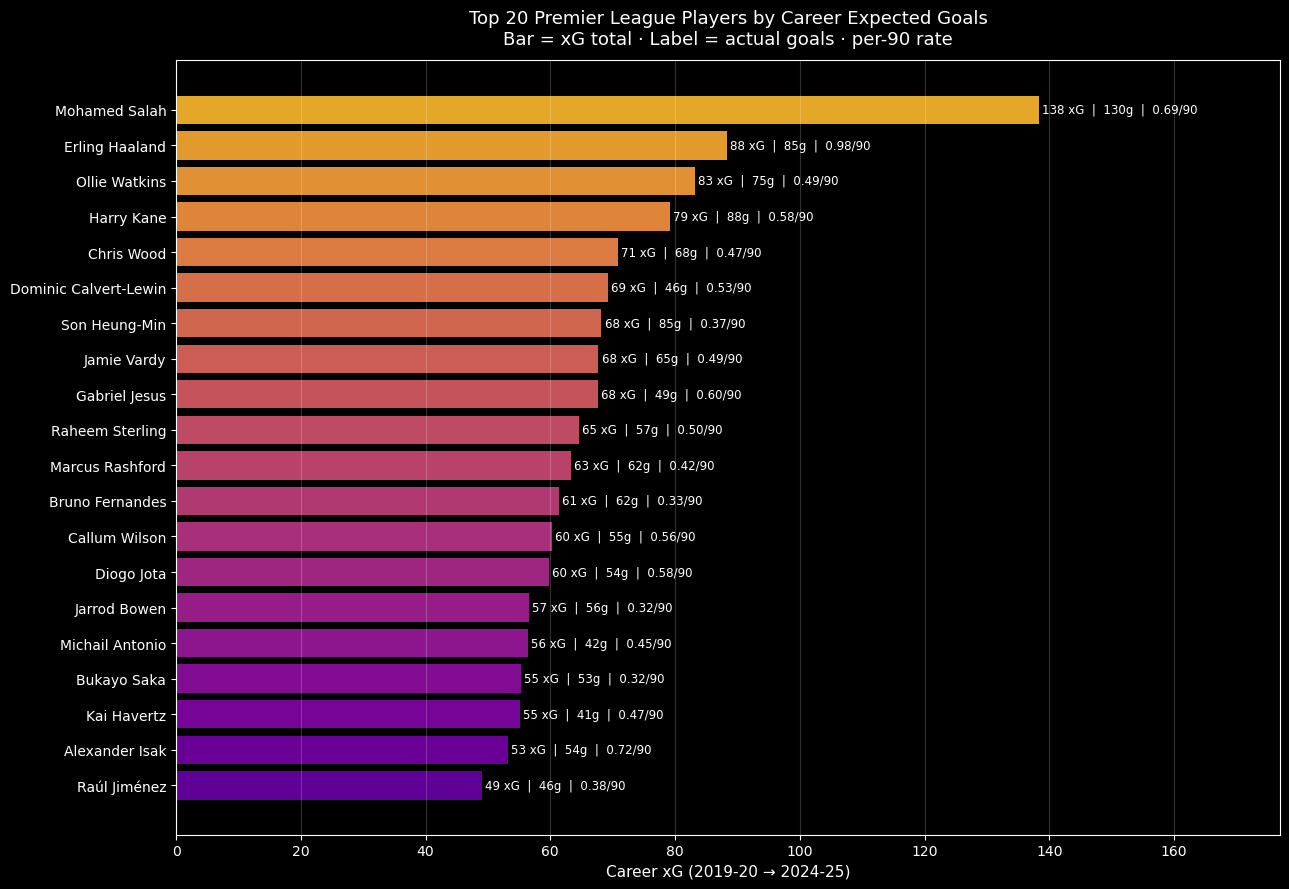

In [15]:
# Top 20 players by career xG — bar chart
top20 = qualified.head(20)

fig, ax = plt.subplots(figsize=(13, 9))
colors_p = plt.cm.plasma(np.linspace(0.2, 0.85, len(top20)))

bars = ax.barh(top20['player'][::-1], top20['xg'][::-1], color=colors_p, alpha=0.9)
for bar, row in zip(bars, top20.iloc[::-1].itertuples()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{row.xg:.0f} xG  |  {row.goals}g  |  {row.xg_p90:.2f}/90',
            va='center', fontsize=8.5)

ax.set_xlabel('Career xG (2019-20 → 2024-25)', fontsize=11)
ax.set_title('Top 20 Premier League Players by Career Expected Goals\nBar = xG total · Label = actual goals · per-90 rate', fontsize=13, pad=12)
ax.grid(axis='x', alpha=0.2)
ax.set_xlim(0, top20['xg'].max() * 1.28)
plt.tight_layout()
plt.show()

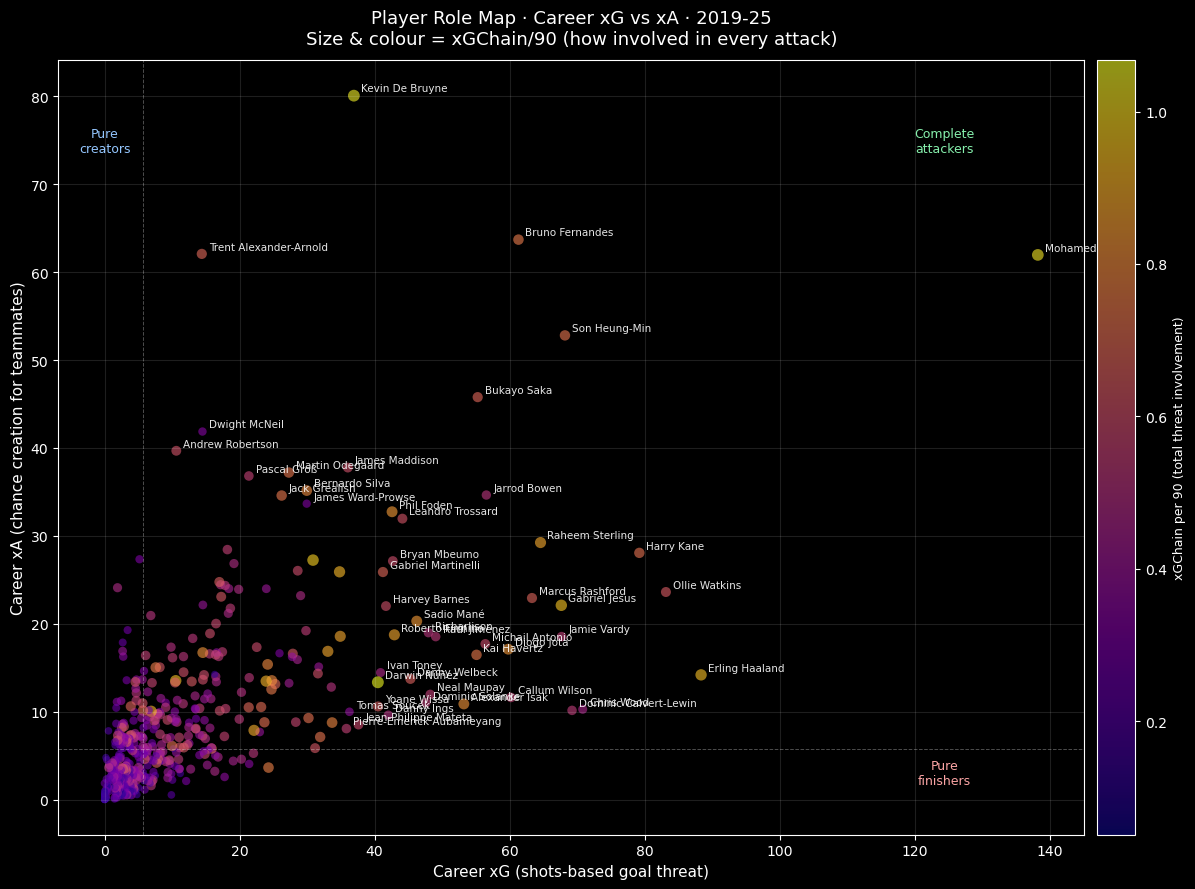

In [16]:
# xG vs xA scatter — four quadrants of player type
# Top-right: goal threat AND creator (Salah, Fernandes)
# Top-left:  pure creator (Trent, De Bruyne)
# Bottom-right: pure finisher (Haaland, Vardy)
# Bottom-left:  neither (low-xG midfielders)

fig, ax = plt.subplots(figsize=(13, 9))

xg_vals = qualified['xg'].values
xa_vals = qualified['xa'].values
chain   = qualified['xgchain_p90'].values  # size = involvement

scatter = ax.scatter(
    xg_vals, xa_vals,
    c=chain, cmap='plasma',
    s=chain * 50 + 20,
    alpha=0.6, linewidths=0,
)

# Label top players
label_mask = (qualified['xg'] > 35) | (qualified['xa'] > 30) | (qualified['xgchain_p90'] > 1.0)
for _, row in qualified[label_mask].iterrows():
    ax.annotate(
        row['player'], (row['xg'], row['xa']),
        textcoords='offset points', xytext=(5, 3),
        fontsize=7.5, alpha=0.9
    )

# Quadrant lines (median)
ax.axvline(qualified['xg'].median(), color='white', lw=0.7, ls='--', alpha=0.3)
ax.axhline(qualified['xa'].median(), color='white', lw=0.7, ls='--', alpha=0.3)

# Quadrant labels
x_med, y_med = qualified['xg'].median(), qualified['xa'].median()
ax.text(xg_vals.max()*0.9, xa_vals.max()*0.92, 'Complete\nattackers', color='#86efac', fontsize=9, ha='center')
ax.text(xg_vals.min()*0.5,  xa_vals.max()*0.92, 'Pure\ncreators',   color='#93c5fd', fontsize=9, ha='center')
ax.text(xg_vals.max()*0.9,  y_med*0.3,          'Pure\nfinishers',  color='#fca5a5', fontsize=9, ha='center')

cb = plt.colorbar(scatter, ax=ax, pad=0.01)
cb.set_label('xGChain per 90 (total threat involvement)', fontsize=9)

ax.set_xlabel('Career xG (shots-based goal threat)', fontsize=11)
ax.set_ylabel('Career xA (chance creation for teammates)', fontsize=11)
ax.set_title('Player Role Map · Career xG vs xA · 2019-25\nSize & colour = xGChain/90 (how involved in every attack)', fontsize=13, pad=12)
ax.grid(True, alpha=0.12)
plt.tight_layout()
plt.show()

---
## 8 · Squad Depth

How reliant is each team on a single player?  
**xG concentration** = top player's xG / team's total xG.  
A score of 0.40 means 40% of the team's expected goals came from one player.  
High concentration = dangerous if that player is injured; low = more resilient squad.

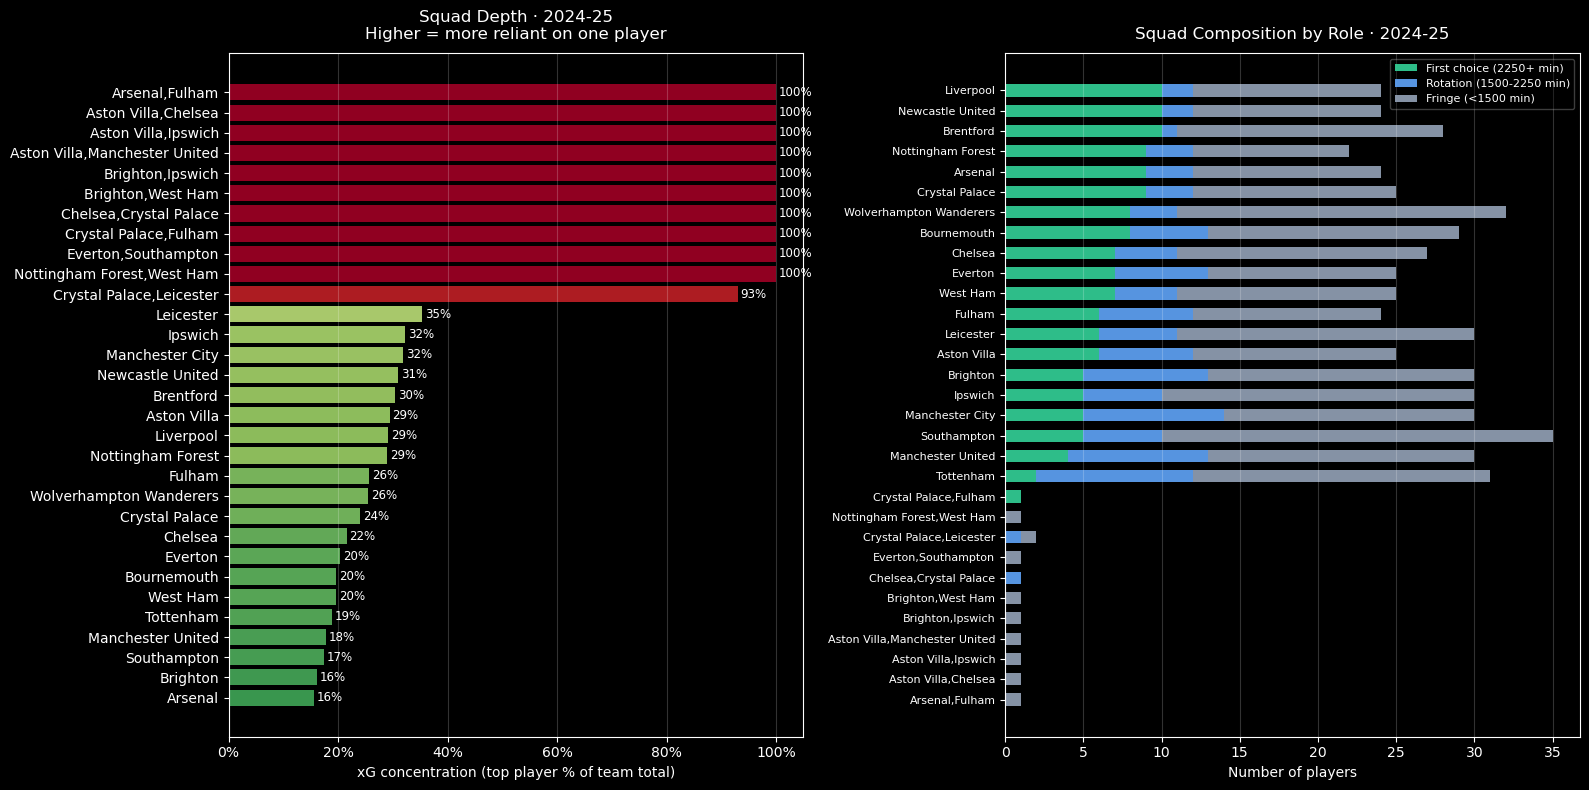

In [17]:
depth_df = pd.read_csv(DATA / 'squad_depth.csv')

# Filter out artefact rows (team name concatenations from groupby edge case)
depth_df = depth_df[depth_df['team'].str.len() < 40].copy()

# Pivot: seasons as columns, teams as rows, value = xg_concentration for 2024-25
latest = depth_df[depth_df['season'] == '2024-25'].sort_values('xg_concentration', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: xG concentration bar chart for 2024-25
ax = axes[0]
bar_colors = plt.cm.RdYlGn_r(latest['xg_concentration'].values / latest['xg_concentration'].max())
bars = ax.barh(latest['team'][::-1], latest['xg_concentration'][::-1], color=bar_colors[::-1], alpha=0.88)
for bar, row in zip(bars, latest.iloc[::-1].itertuples()):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{row.xg_concentration:.0%}',
            va='center', fontsize=8.5)
ax.set_xlabel('xG concentration (top player % of team total)', fontsize=10)
ax.set_title('Squad Depth · 2024-25\nHigher = more reliant on one player', fontsize=12, pad=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(axis='x', alpha=0.2)

# Right: first-choice vs rotation vs fringe squad composition
ax2 = axes[1]
latest_sorted = latest.sort_values('first_choice')
width = 0.6
fc  = latest_sorted['first_choice'].values
rot = latest_sorted['rotation'].values
fri = latest_sorted['fringe'].values
y   = range(len(latest_sorted))
ylab= latest_sorted['team'].tolist()

ax2.barh(y, fc,  height=width, color='#34d399', alpha=0.9, label='First choice (2250+ min)')
ax2.barh(y, rot, height=width, left=fc,       color='#60a5fa', alpha=0.9, label='Rotation (1500-2250 min)')
ax2.barh(y, fri, height=width, left=fc+rot,   color='#94a3b8', alpha=0.9, label='Fringe (<1500 min)')
ax2.set_yticks(y); ax2.set_yticklabels(ylab, fontsize=8)
ax2.set_xlabel('Number of players', fontsize=10)
ax2.set_title('Squad Composition by Role · 2024-25', fontsize=12, pad=10)
ax2.legend(fontsize=8, framealpha=0.3)
ax2.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

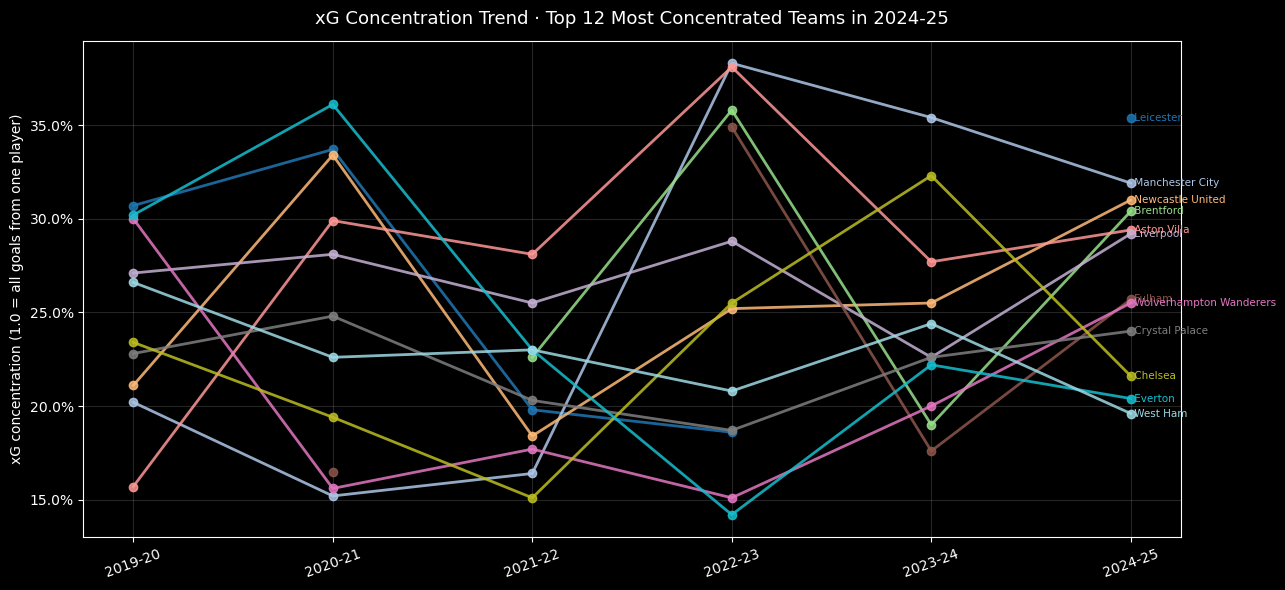


Key question: if your top xG contributor misses 10 games, how much does your attack drop?
That's what xG concentration measures — and it's something your Poisson model currently ignores.


In [18]:
# xG concentration trend across seasons — which teams have become MORE/LESS reliant over time
pivot = depth_df.pivot_table(index='team', columns='season', values='xg_concentration')

# Only show teams that appeared in at least 4 seasons
pivot = pivot[pivot.notna().sum(axis=1) >= 4].dropna(subset=['2024-25'])
pivot = pivot.sort_values('2024-25', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(13, 6))
seasons_cols = [c for c in ['2019-20','2020-21','2021-22','2022-23','2023-24','2024-25'] if c in pivot.columns]
colors_trend = plt.cm.tab20(np.linspace(0, 1, len(pivot)))

for i, (team, row) in enumerate(pivot.iterrows()):
    vals = [row[s] for s in seasons_cols]
    ax.plot(seasons_cols, vals, 'o-', lw=2, markersize=6, label=team, color=colors_trend[i], alpha=0.85)
    ax.text(seasons_cols[-1], vals[-1], f' {team}', va='center', fontsize=7.5, color=colors_trend[i])

ax.set_ylabel('xG concentration (1.0 = all goals from one player)', fontsize=10)
ax.set_title('xG Concentration Trend · Top 12 Most Concentrated Teams in 2024-25', fontsize=13, pad=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(True, alpha=0.15)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print("\nKey question: if your top xG contributor misses 10 games, how much does your attack drop?")
print("That's what xG concentration measures — and it's something your Poisson model currently ignores.")

---
## 9 · Championship 2024-25 — Promoted Teams & 2025-26 Preview

Three sides are promoted from the Championship each season:
- **Positions 1 & 2** — automatic promotion (champions and runners-up)
- **Positions 3–6** — two-legged semi-finals + Wembley final (the "playoffs")

We fetch the Championship data from Football-Data.co.uk, compute the final regular-season table,
and identify the three promoted teams.  
For the 2025-26 preview we assign promoted sides a starting Elo equal to the mean of the
three relegated sides they replace — a reasonable prior that they're of similar quality.

In [19]:
champ_table = pd.read_csv('data/championship_table.csv', index_col=0)
promoted_df = pd.read_csv('data/promoted_teams.csv')

# confirmed = auto-promoted (top 2) or playoff winner; candidates = playoff spots 3-6
confirmed  = promoted_df[promoted_df['method'].isin(['auto_promoted', 'playoff_winner'])]
candidates = promoted_df[promoted_df['method'] == 'playoff_candidate']
promoted   = confirmed['team'].tolist()

METHOD_LABEL = {'auto_promoted': 'Auto-promoted', 'playoff_winner': 'Playoff winners'}
POS_LABEL    = {1: 'Champions', 2: 'Runners-up'}

print('Championship 2025-26 — Current Table (top 10):')
print(champ_table.head(10).to_string())
print('\nLeading promotion candidates for Premier League 2026-27:')
for _, row in confirmed.iterrows():
    pos = POS_LABEL.get(row.champ_position, f"Position {int(row.champ_position)}")
    mth = METHOD_LABEL.get(row.method, row.method)
    print(f"  {row.team}  ({pos}, {mth})")
if not candidates.empty:
    print(f"\n  Playoff places (not yet confirmed): {candidates['team'].tolist()}")
    print("  Re-run ./fetch_data.sh after the playoff final to confirm the winner.")


Championship 2025-26 — Current Table (top 10):
                Team  Pts  GD  GF
1              Leeds  100  65  95
2            Burnley  100  53  69
3   Sheffield United   92  27  63
4         Sunderland   76  14  58
5           Coventry   69   6  64
6       Bristol City   68   4  59
7          Blackburn   66   5  53
8           Millwall   66  -2  47
9          West Brom   64  10  57
10     Middlesbrough   64   8  64

Leading promotion candidates for Premier League 2026-27:
  Leeds  (Champions, Auto-promoted)
  Burnley  (Runners-up, Auto-promoted)
  Sunderland  (Position 4, Playoff winners)


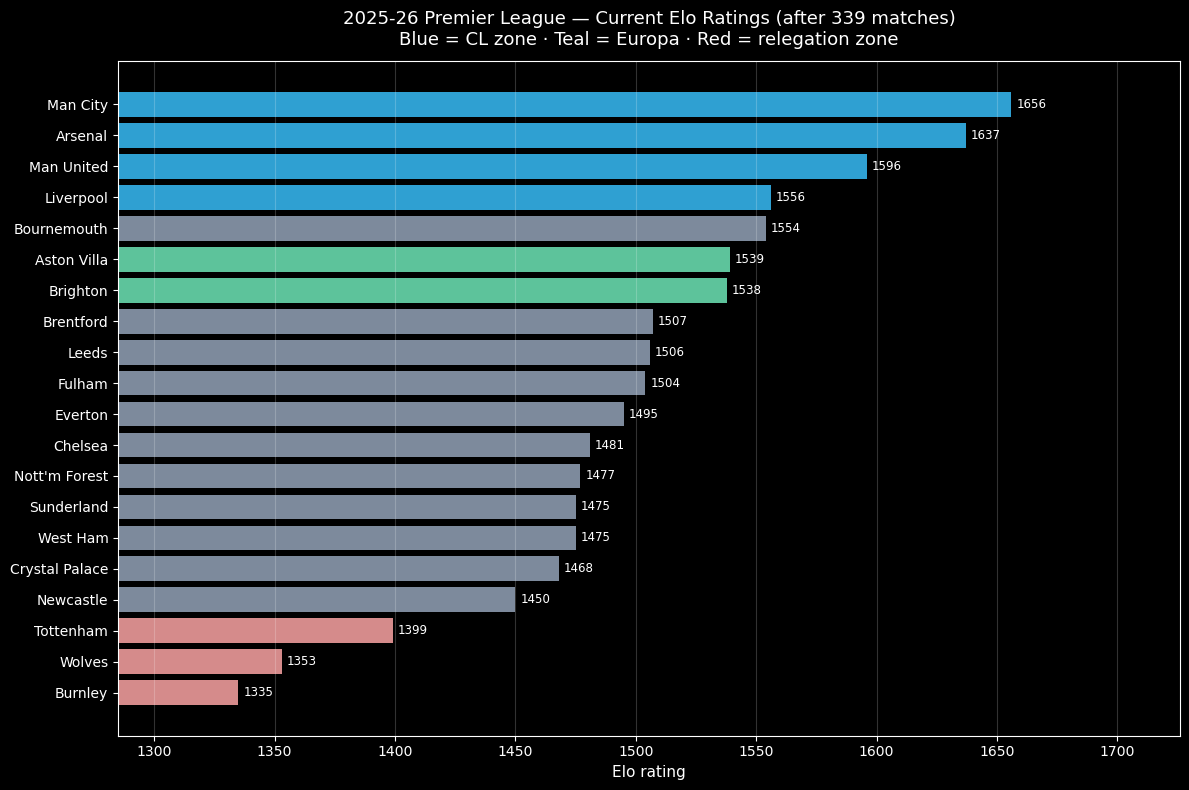


Current league position vs Elo rating (GW~33):
 LeaguePos           Team  Elo
         1        Arsenal 1637
         2       Man City 1656
         3     Man United 1596
         4      Liverpool 1556
         5    Aston Villa 1539
         6       Brighton 1538
         7    Bournemouth 1554
         8        Chelsea 1481
         9      Brentford 1507
        10         Fulham 1504
        11        Everton 1495
        12     Sunderland 1475
        13 Crystal Palace 1468
        14      Newcastle 1450
        15          Leeds 1506
        16  Nott'm Forest 1477
        17       West Ham 1475
        18      Tottenham 1399
        19        Burnley 1335
        20         Wolves 1353


In [20]:
# Current Elo ratings — colour by position zone
n_played_gw = len(played) // 10  # approximate gameweek

elo_rows = [{'Team': t, 'Elo': round(elo[t])} for t in teams]
elo_df = (pd.DataFrame(elo_rows)
            .sort_values('Elo', ascending=False)
            .reset_index(drop=True))
elo_df.index += 1

# Map team → current league position (from actual_df)
pos_map = {row.Team: int(row.Index) for row in actual_df.itertuples()}

def zone_color(pos):
    if pos <= 4:  return '#38bdf8'   # Champions League
    if pos <= 6:  return '#6ee7b7'   # Europa
    if pos >= 18: return '#fca5a5'   # Relegation
    return '#94a3b8'                  # Mid-table

elo_df['LeaguePos'] = elo_df['Team'].map(pos_map).fillna(10).astype(int)
elo_df['Color'] = elo_df['LeaguePos'].apply(zone_color)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(elo_df['Team'][::-1], elo_df['Elo'][::-1],
               color=elo_df['Color'][::-1].tolist(), alpha=0.85)
for bar, val in zip(bars, elo_df['Elo'][::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=8.5)
ax.set_xlabel('Elo rating', fontsize=11)
ax.set_title(
    f'2025-26 Premier League — Current Elo Ratings (after {len(played)} matches)\n'
    'Blue = CL zone · Teal = Europa · Red = relegation zone',
    fontsize=13, pad=12
)
ax.set_xlim(elo_df['Elo'].min() - 50, elo_df['Elo'].max() + 70)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(OUT / 'elo_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nCurrent league position vs Elo rating (GW~{n_played_gw}):')
print(elo_df[['LeaguePos','Team','Elo']].sort_values('LeaguePos').to_string(index=False))


---
## 10 · Bookmaker Calibration (2024-25 in-sample check)

To verify the model's probability estimates are sensible, we compare predicted  
win/draw/loss probabilities against devigged Bet365 odds for the second half of 2024-25 (GW20-38).

Since we now train on the full 2024-25 season, this is an **in-sample** check —  
it tells us whether the model's probabilities are on the right scale, not whether they'll generalise.  
A close match between model and market is a good sign; large gaps suggest the model is miscalibrated.

**Devigging:** divide each implied probability by the overround (~1.05) to get fair odds that sum to 1.

Matches with odds: 149
Outcome        Model mean   Market mean
Home win            0.437         0.435
Draw                0.244         0.246
Away win            0.319         0.319


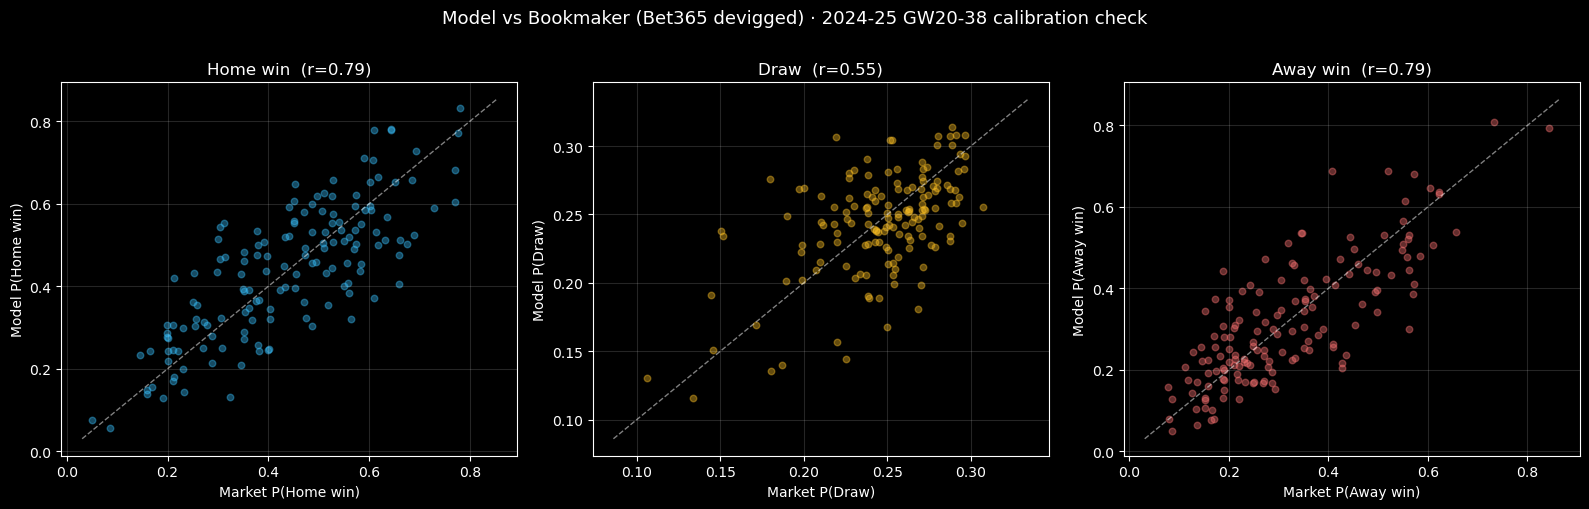

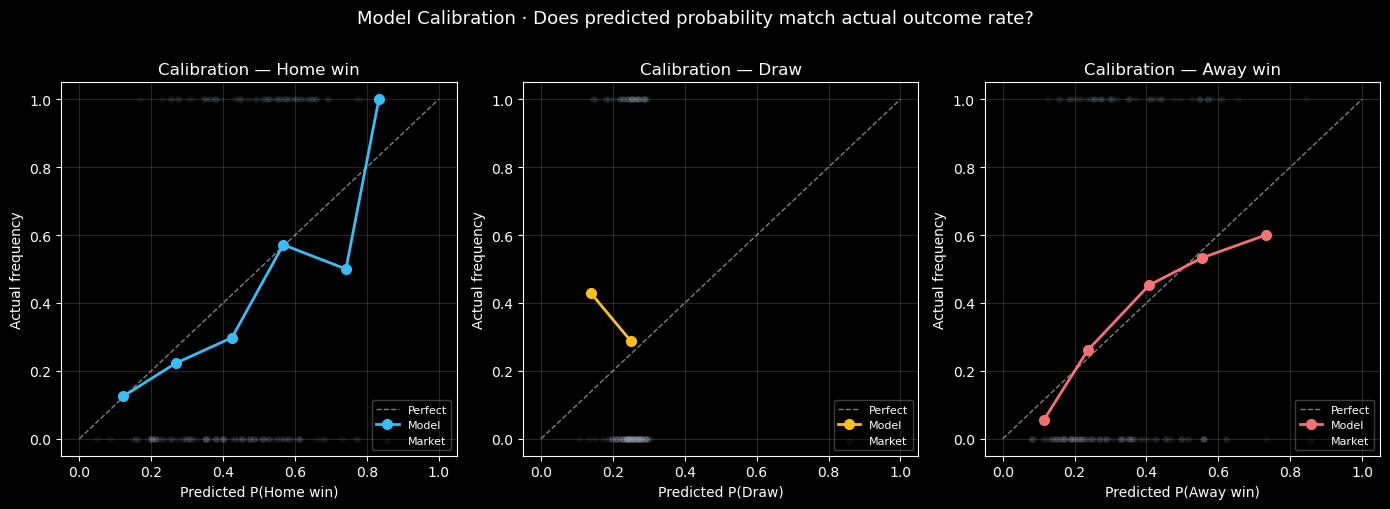


Matches where model most disagrees with market (home win probability):
      Date       HomeTeam   AwayTeam    mdl_H    mkt_H   edge_H FTR
2026-04-12 Crystal Palace  Newcastle 0.552382 0.312796 0.239586   H
2026-03-21       Brighton  Liverpool 0.542539 0.303508 0.239031   H
2026-02-10      Tottenham  Newcastle 0.515358 0.299094 0.216264   A
2026-02-10       West Ham Man United 0.420526 0.211932 0.208593   D
2026-04-18      Brentford     Fulham 0.648259 0.453278 0.194981   D

(negative edge = market more bullish on home than model)
      Date      HomeTeam       AwayTeam    mdl_H    mkt_H    edge_H FTR
2026-04-25     Liverpool Crystal Palace 0.406518 0.658588 -0.252070   H
2026-01-07     Newcastle          Leeds 0.319505 0.563865 -0.244360   H
2026-02-10       Chelsea          Leeds 0.371652 0.609836 -0.238184   D
2026-01-31        Wolves    Bournemouth 0.131503 0.323683 -0.192180   A
2026-02-01 Nott'm Forest Crystal Palace 0.303520 0.486111 -0.182591   D


In [21]:
from scipy.stats import poisson as _sp

def match_probs_dc(lh, la, rho, max_g=10):
    """Compute P(home win), P(draw), P(away win) from DC-corrected Poisson."""
    g = np.outer(_sp.pmf(np.arange(max_g + 1), lh),
                 _sp.pmf(np.arange(max_g + 1), la))
    for i in range(2):
        for j in range(2):
            g[i, j] *= dc_tau(i, j, lh, la, rho)
    g = np.clip(g, 0, None)
    g /= g.sum()
    return np.tril(g, -1).sum(), np.diag(g).sum(), np.triu(g, 1).sum()

# Load Bet365 odds for GW20-38 of 2024-25
_SPLIT = 190
odds = df_raw.iloc[_SPLIT:][['Date', 'HomeTeam', 'AwayTeam', 'B365H', 'B365D', 'B365A', 'FTR']].copy()
odds = odds.reset_index(drop=True).dropna(subset=['B365H', 'B365D', 'B365A'])

# Join form context from the full-season matches dataframe
_form_lookup = matches[['HomeTeam', 'AwayTeam', 'home_form5', 'away_form5']]
odds = odds.merge(_form_lookup, on=['HomeTeam', 'AwayTeam'], how='left')
odds['_fd'] = odds['home_form5'].fillna(0) - odds['away_form5'].fillna(0)

# Compute match lambdas using full-season 2024-25 parameters
_lam_h = np.array([
    np.exp(attack[h] + defence[a] + home_adv[h] + form_coeff * fd)
    for h, a, fd in zip(odds['HomeTeam'], odds['AwayTeam'], odds['_fd'])
])
_lam_a = np.array([
    np.exp(attack[a] + defence[h] - form_coeff * fd)
    for h, a, fd in zip(odds['HomeTeam'], odds['AwayTeam'], odds['_fd'])
])

# Devig: remove bookmaker overround to get fair probabilities
odds['_or'] = 1/odds['B365H'] + 1/odds['B365D'] + 1/odds['B365A']
odds['mkt_H'] = (1/odds['B365H']) / odds['_or']
odds['mkt_D'] = (1/odds['B365D']) / odds['_or']
odds['mkt_A'] = (1/odds['B365A']) / odds['_or']

# Compute model probabilities
mdl_h, mdl_d, mdl_a = [], [], []
for i in range(len(odds)):
    ph, pd_, pa = match_probs_dc(_lam_h[i], _lam_a[i], rho)
    mdl_h.append(ph); mdl_d.append(pd_); mdl_a.append(pa)
odds['mdl_H'] = mdl_h
odds['mdl_D'] = mdl_d
odds['mdl_A'] = mdl_a

print(f'Matches with odds: {len(odds)}')
print(f'{"Outcome":<12} {"Model mean":>12} {"Market mean":>13}')
for label, mc, mk in [('Home win','mdl_H','mkt_H'),('Draw','mdl_D','mkt_D'),('Away win','mdl_A','mkt_A')]:
    print(f'{label:<12} {odds[mc].mean():>12.3f} {odds[mk].mean():>13.3f}')

# ── Scatter: model vs market ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
configs = [('mdl_H','mkt_H','Home win','#38bdf8','H'),
           ('mdl_D','mkt_D','Draw',    '#fbbf24','D'),
           ('mdl_A','mkt_A','Away win','#f87171','A')]

for ax, (mc, mk, label, color, ftr) in zip(axes, configs):
    ax.scatter(odds[mk], odds[mc], alpha=0.4, s=22, color=color)
    lo = min(odds[mk].min(), odds[mc].min()) - 0.02
    hi = max(odds[mk].max(), odds[mc].max()) + 0.02
    ax.plot([lo, hi], [lo, hi], 'w--', lw=1, alpha=0.5)
    r = np.corrcoef(odds[mk], odds[mc])[0, 1]
    ax.set_xlabel(f'Market P({label})', fontsize=10)
    ax.set_ylabel(f'Model P({label})',  fontsize=10)
    ax.set_title(f'{label}  (r={r:.2f})', fontsize=12)
    ax.grid(True, alpha=0.15)

fig.suptitle('Model vs Bookmaker (Bet365 devigged) · 2024-25 GW20-38 calibration check', fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig(OUT / 'bookie_scatter.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Calibration: does model P(X) match actual rate of X? ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (mc, mk, label, color, ftr) in zip(axes, configs):
    odds['actual'] = (odds['FTR'] == ftr).astype(int)
    bins = np.linspace(0, 1, 7)
    grp  = odds.groupby(pd.cut(odds[mc], bins=bins, include_lowest=True))
    mid  = grp[mc].mean().dropna()
    freq = grp['actual'].mean().reindex(mid.index)
    ax.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.5, label='Perfect')
    ax.plot(mid, freq, 'o-', color=color, lw=2, ms=7, label='Model')
    ax.scatter(odds[mk], odds['actual'], alpha=0.07, s=14, color='#94a3b8', label='Market')
    ax.set_xlabel(f'Predicted P({label})', fontsize=10)
    ax.set_ylabel('Actual frequency',      fontsize=10)
    ax.set_title(f'Calibration — {label}', fontsize=12)
    ax.legend(fontsize=8, framealpha=0.3)
    ax.grid(True, alpha=0.15)

fig.suptitle('Model Calibration · Does predicted probability match actual outcome rate?', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# ── Where does the model diverge most from the market? ────────────────────────
odds['edge_H'] = odds['mdl_H'] - odds['mkt_H']
print('\nMatches where model most disagrees with market (home win probability):')
print(odds.nlargest(5, 'edge_H')[['Date','HomeTeam','AwayTeam','mdl_H','mkt_H','edge_H','FTR']].to_string(index=False))
print('\n(negative edge = market more bullish on home than model)')
print(odds.nsmallest(5, 'edge_H')[['Date','HomeTeam','AwayTeam','mdl_H','mkt_H','edge_H','FTR']].to_string(index=False))

---
## 2025-26 Season Prediction

Parameters fitted on all 380 matches of 2024-25.
Promoted sides (Leeds, Burnley, Sunderland) enter with the average parameters of the three relegated teams (Southampton, Leicester, Ipswich).

---
## §4 · Monte Carlo Simulation

### What is Monte Carlo simulation?

Instead of computing the probability of each final table analytically (intractable), we
*simulate the remaining season thousands of times* and count outcomes.

Each simulated run:
1. Take the **actual current standings** (points, GD) as the starting point
2. For each of the **remaining fixtures** (all unplayed home/away pairs), draw a random
   scoreline from the Poisson distributions fitted in §3
3. Apply PL points rules and add to the actual current points
4. Rank the 20 teams to get one simulated final table

Repeat **10,000 times**. The fraction of runs where a team finishes 1st is their title probability.

### Starting from actual points

This is the key difference from a full cold-start simulation. Because we have real data:
- A team on 80 points with 4 games to play has a very high chance of winning the league
- A team on 20 points with 4 games to play is almost certainly relegated

The Monte Carlo captures the uncertainty in those remaining games while anchoring to what
has actually happened.

### How each fixture is scored

For home team H vs away team A:

$$\lambda_H = \exp(\alpha_H - \beta_A + \theta_H) \qquad \lambda_A = \exp(\alpha_A - \beta_H)$$

Goals are drawn: `score_H ~ Poisson(λ_H)`, `score_A ~ Poisson(λ_A)`.  
The ρ rejection sampler corrects the known under-prediction of 0–0 and 1–1 results.

### Why 10,000 runs?

With ~40 remaining fixtures, sampling noise is ~±1%. More runs give diminishing returns
since the model parameter uncertainty dominates.

### Limitation

We don't have exact dates or fixture assignments for the remaining games (which team plays
who in GW35 vs GW38). We use all unplayed home/away pairs and treat them as stateless draws —
form within those specific remaining games can't be applied. But the parameters themselves
were fitted on the full 330+ match history, so team quality is well-estimated.


In [22]:
N_SIMS = 10_000
rng    = np.random.default_rng(42)

fix_h = [h for h, a in remaining]
fix_a = [a for h, a in remaining]
n_fix = len(remaining)

# Precompute expected goals for each remaining fixture (no form — no dates)
lam_h_ = np.array([
    np.exp(attack[h] + defence[a] + home_adv[h])
    for h, a in zip(fix_h, fix_a)
])
lam_a_ = np.array([
    np.exp(attack[a] + defence[h])
    for h, a in zip(fix_h, fix_a)
])

# Max τ per fixture for ρ rejection sampling
max_tau_ = np.array([
    max(1.0 - lh*la*rho, 1.0 + la*rho, 1.0 + lh*rho, 1.0 - rho, 1.0)
    for lh, la in zip(lam_h_, lam_a_)
])

finish_counts = np.zeros((n_2526, n_2526), dtype=int)
pts_dist      = np.zeros((n_2526, N_SIMS),  dtype=int)

print(f'Simulating {n_fix} remaining fixtures × {N_SIMS:,} runs ...')
for sim in range(N_SIMS):
    hg_sim = rng.poisson(lam_h_)
    ag_sim = rng.poisson(lam_a_)

    # ρ rejection sampling for low-scoring results
    for i in range(n_fix):
        hg, ag = int(hg_sim[i]), int(ag_sim[i])
        if hg <= 1 and ag <= 1:
            lh, la, mt = lam_h_[i], lam_a_[i], max_tau_[i]
            t_val = dc_tau(hg, ag, lh, la, rho)
            while t_val / mt < rng.random():
                hg = rng.poisson(lh)
                ag = rng.poisson(la)
                t_val = dc_tau(hg, ag, lh, la, rho)
            hg_sim[i], ag_sim[i] = hg, ag

    # Start from actual current points + GD
    pts = actual_pts_arr.copy()
    gd  = actual_gd_arr.copy()
    for i in range(n_fix):
        hi, ai = tidx_2526[fix_h[i]], tidx_2526[fix_a[i]]
        hg, ag = int(hg_sim[i]), int(ag_sim[i])
        gd[hi] += hg - ag; gd[ai] += ag - hg
        if hg > ag:    pts[hi] += 3
        elif hg == ag: pts[hi] += 1; pts[ai] += 1
        else:          pts[ai] += 3

    order = np.lexsort((-gd, -pts))
    for pos, ti in enumerate(order):
        finish_counts[ti, pos] += 1
    pts_dist[:, sim] = pts

finish_pct = finish_counts / N_SIMS * 100
mean_pts   = pts_dist.mean(axis=1)

summary = pd.DataFrame({
    'Team'     : teams_2526,
    'CurPts'   : [actual_pts[t] for t in teams_2526],
    'MeanFinalPts': mean_pts.round(1),
    'P(1st)%'  : finish_pct[:, 0].round(1),
    'P(Top4)%' : finish_pct[:, :4].sum(axis=1).round(1),
    'P(Top6)%' : finish_pct[:, :6].sum(axis=1).round(1),
    'P(Rel)%'  : finish_pct[:, -3:].sum(axis=1).round(1),
})
summary = summary.sort_values('CurPts', ascending=False).reset_index(drop=True)
summary.index += 1
print(f'Projected 2025-26 final table ({len(remaining)} fixtures remaining):')
summary


Simulating 41 remaining fixtures × 10,000 runs ...
Projected 2025-26 final table (41 fixtures remaining):


,Team,CurPts,MeanFinalPts,P(1st)%,P(Top4)%,P(Top6)%,P(Rel)%
1,Arsenal,73,81.5,60.5,100.0,100.0,0.0
2,Man City,70,80.4,39.5,100.0,100.0,0.0
3,Man United,61,67.2,0.0,93.1,100.0,0.0
4,Aston Villa,58,64.4,0.0,63.7,99.7,0.0
5,Liverpool,58,62.9,0.0,42.6,98.0,0.0
6,Brighton,50,56.8,0.0,0.5,46.2,0.0
7,Bournemouth,49,55.1,0.0,0.0,16.4,0.0
8,Brentford,48,53.7,0.0,0.0,6.0,0.0
9,Fulham,48,53.2,0.0,0.0,3.9,0.0
10,Chelsea,48,55.6,0.0,0.1,27.4,0.0


### 2025-26 Prediction

2025-26 hasn't happened yet — so below is purely the model's forward prediction.  
Mean predicted points is the best single ranking; the probability columns show how certain or uncertain the model is about each team's fate.

In [23]:
# Most likely finishing position per team (modal position across 10k sims)
most_likely = {teams_2526[i]: int(finish_counts[i].argmax()) + 1 for i in range(n_2526)}
summary_disp = summary.copy()
summary_disp.insert(3, 'MostLikelyPos', [most_likely[t] for t in summary_disp['Team']])

print(f'2025-26 Premier League — projected final table ({len(remaining)} remaining fixtures):')
summary_disp


2025-26 Premier League — projected final table (41 remaining fixtures):


,Team,CurPts,MeanFinalPts,MostLikelyPos,P(1st)%,P(Top4)%,P(Top6)%,P(Rel)%
1,Arsenal,73,81.5,1,60.5,100.0,100.0,0.0
2,Man City,70,80.4,2,39.5,100.0,100.0,0.0
3,Man United,61,67.2,3,0.0,93.1,100.0,0.0
4,Aston Villa,58,64.4,4,0.0,63.7,99.7,0.0
5,Liverpool,58,62.9,5,0.0,42.6,98.0,0.0
6,Brighton,50,56.8,6,0.0,0.5,46.2,0.0
7,Bournemouth,49,55.1,8,0.0,0.0,16.4,0.0
8,Brentford,48,53.7,9,0.0,0.0,6.0,0.0
9,Fulham,48,53.2,10,0.0,0.0,3.9,0.0
10,Chelsea,48,55.6,7,0.0,0.1,27.4,0.0


---
## 5 · Output Charts

Three visualisations summarising the simulation results.

### Chart 1 — Title / Top-4 / Relegation probabilities

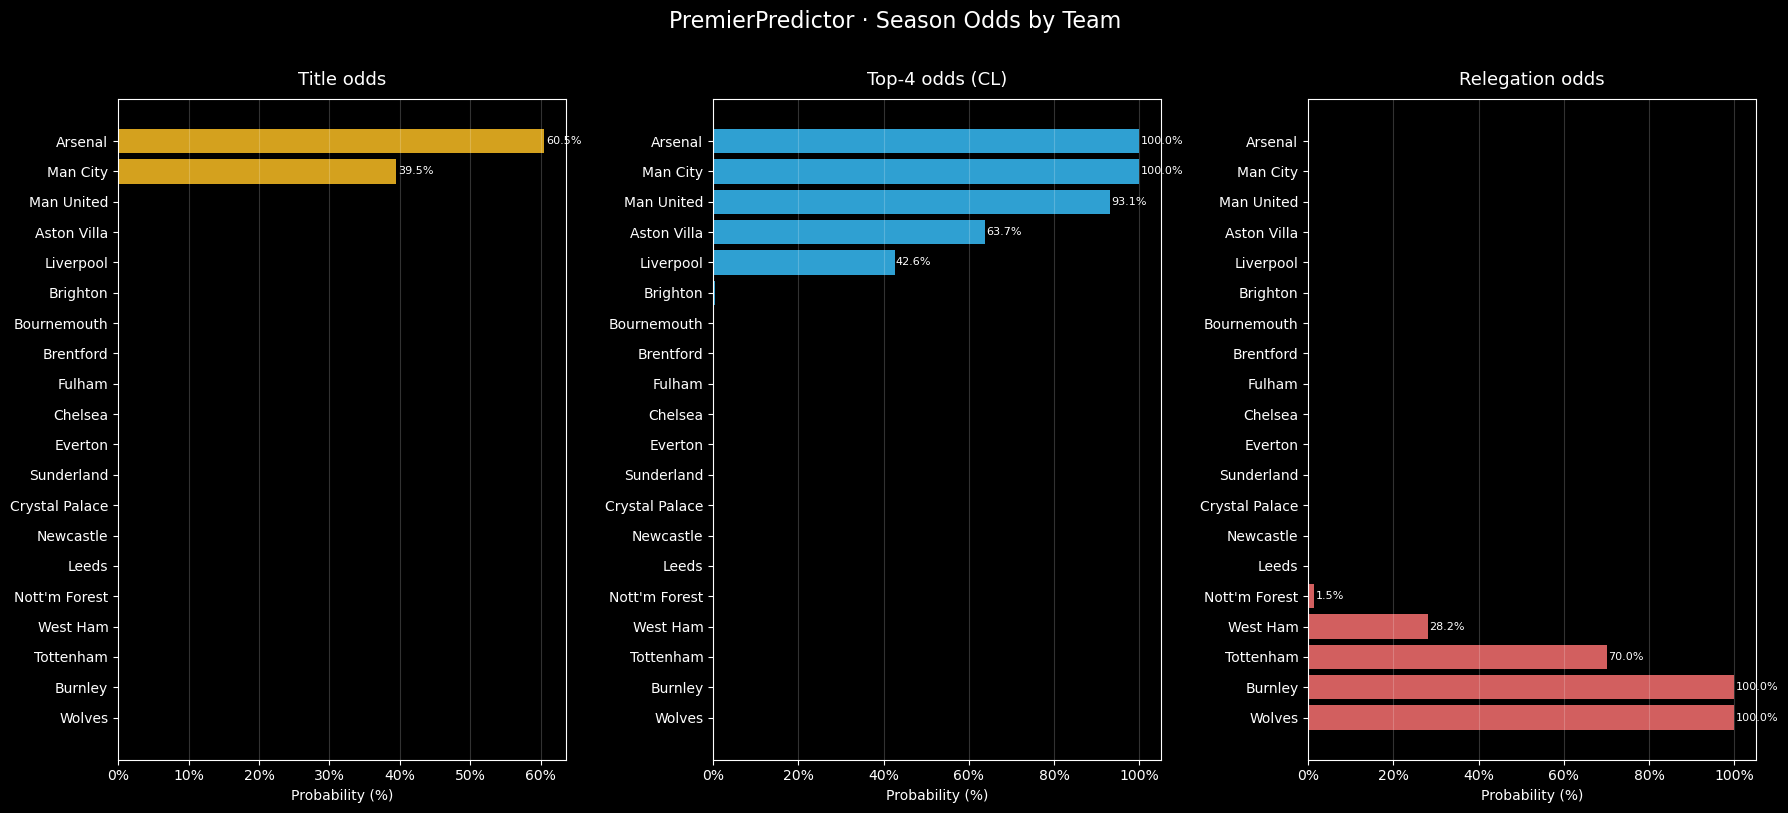

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
ordered_teams = summary['Team'].tolist()

scenarios = [
    ('P(1st)%',  'Title odds',        '#fbbf24'),
    ('P(Top4)%', 'Top-4 odds (CL)',   '#38bdf8'),
    ('P(Rel)%',  'Relegation odds',   '#f87171'),
]

for ax, (col, title, color) in zip(axes, scenarios):
    vals = [summary.loc[summary['Team'] == t, col].values[0] for t in ordered_teams]
    bars = ax.barh(ordered_teams[::-1], vals[::-1], color=color, alpha=0.85)
    ax.set_xlabel('Probability (%)', fontsize=10)
    ax.set_title(title, fontsize=13, pad=10)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.grid(axis='x', alpha=0.2)
    for bar, val in zip(bars, vals[::-1]):
        if val > 0.5:
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=8)

fig.suptitle('PremierPredictor · Season Odds by Team', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'odds_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — Points distribution for top 6 contenders

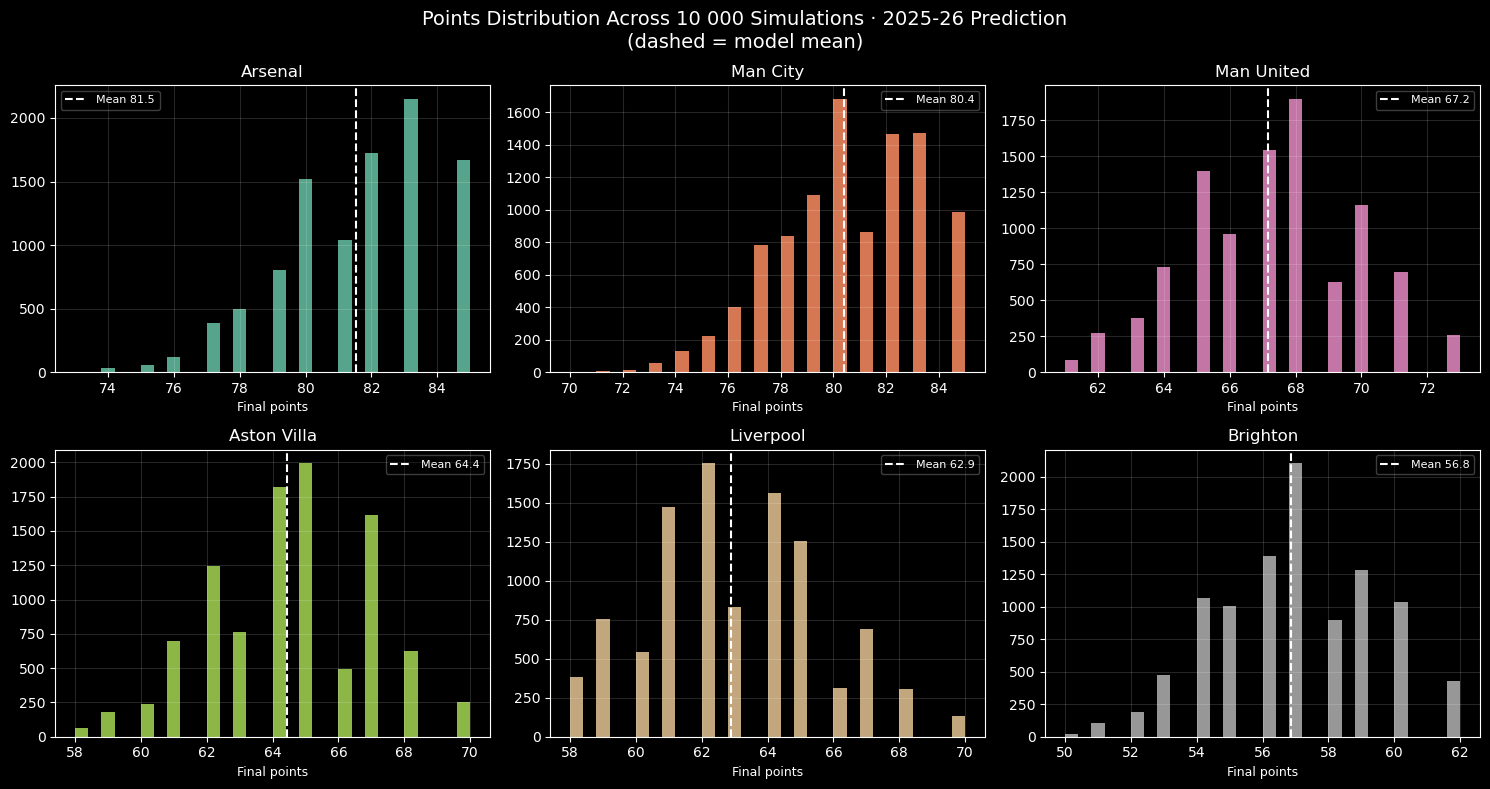

In [25]:
top6 = summary.head(6)['Team'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = plt.cm.Set2(np.linspace(0, 1, 6))

for ax, team, color in zip(axes.flat, top6, colors):
    ti = tidx_2526[team]
    data = pts_dist[ti]
    ax.hist(data, bins=30, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(data.mean(), color='white', lw=1.5, ls='--', label=f'Mean {data.mean():.1f}')
    ax.set_title(team, fontsize=12)
    ax.set_xlabel('Final points', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.3)
    ax.grid(True, alpha=0.15)

fig.suptitle('Points Distribution Across 10 000 Simulations · 2025-26 Prediction\n(dashed = model mean)', fontsize=14)
plt.tight_layout()
plt.savefig(OUT / 'points_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3 — Feature importance: attack & defence rankings

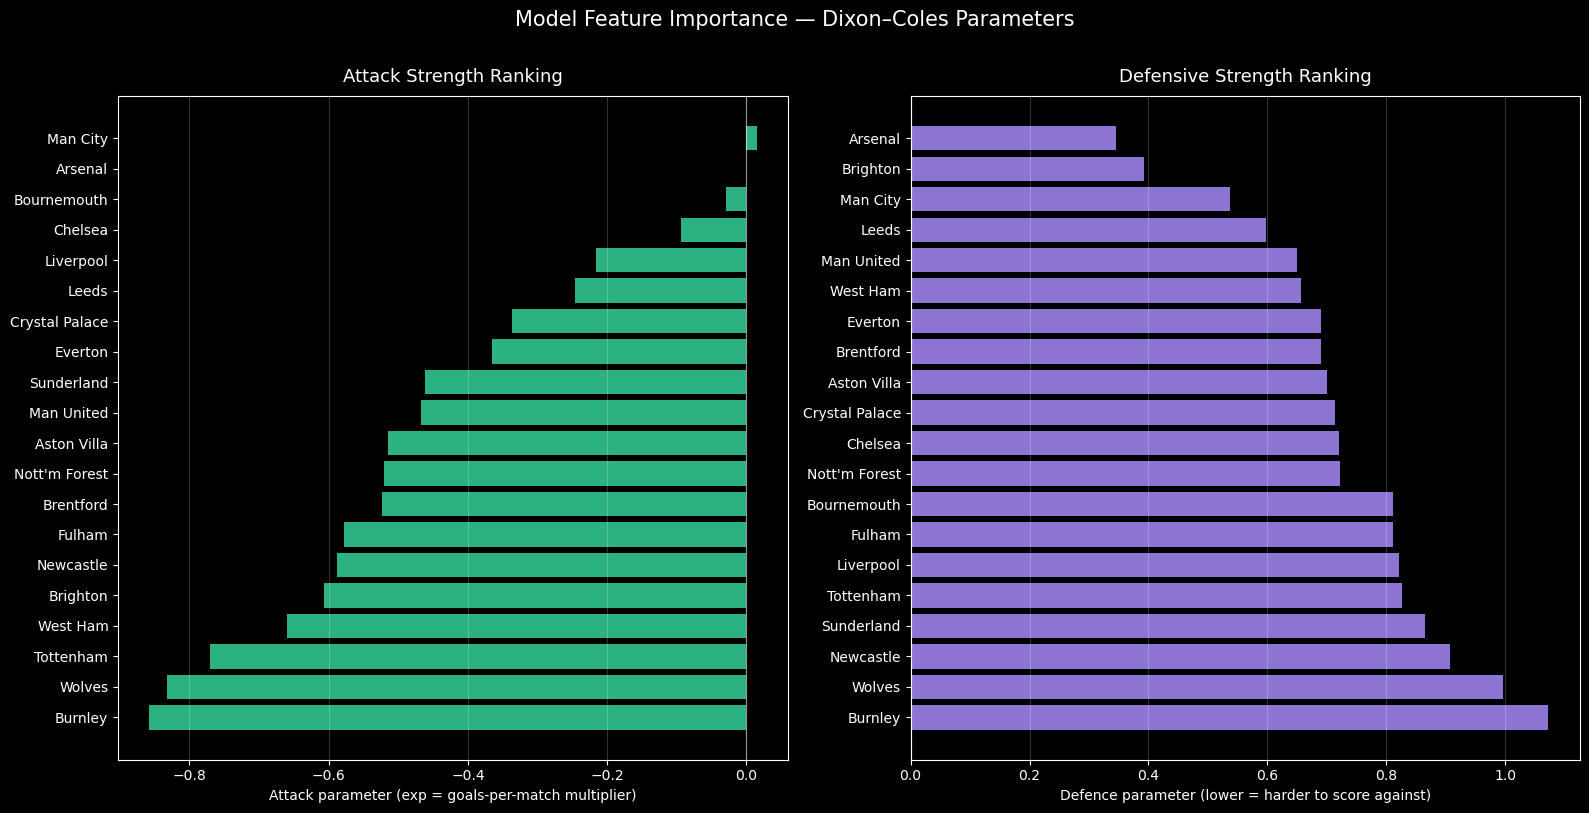

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

atk_sorted = params_df.sort_values('Attack', ascending=True)
def_sorted = params_df.sort_values('Defence', ascending=False)  # lower = better defence

ax1.barh(atk_sorted['Team'], atk_sorted['Attack'], color='#34d399', alpha=0.85)
ax1.axvline(0, color='white', lw=0.8, alpha=0.5)
ax1.set_xlabel('Attack parameter (exp = goals-per-match multiplier)', fontsize=10)
ax1.set_title('Attack Strength Ranking', fontsize=13, pad=10)
ax1.grid(axis='x', alpha=0.2)

ax2.barh(def_sorted['Team'], def_sorted['Defence'], color='#a78bfa', alpha=0.85)
ax2.axvline(0, color='white', lw=0.8, alpha=0.5)
ax2.set_xlabel('Defence parameter (lower = harder to score against)', fontsize=10)
ax2.set_title('Defensive Strength Ranking', fontsize=13, pad=10)
ax2.grid(axis='x', alpha=0.2)

fig.suptitle('Model Feature Importance — Dixon–Coles Parameters', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Notes & next steps

**What we built:**
- Elo ratings from scratch (~30 lines)
- Dixon–Coles Poisson log-likelihood maximised with L-BFGS-B, fitted on **xG** (continuous goals proxy)
- Time-decay ξ — recent matches weighted more heavily; bounded to prevent in-sample overfitting
- Per-team home advantage — Anfield ≠ Goodison as model parameters
- Low-score correction ρ — fixes known 0-0/1-1 bias vs pure Poisson; fitted separately on integer goals
- Form as model input — adaptive rolling window (grid-searched over 3/5/8 games) shifts λ
- Monte Carlo simulation (10,000 × remaining fixtures) seeded with actual current standings
- Bookmaker calibration (§10) — devigged odds vs model probabilities
- Championship data pipeline — auto-detects promoted teams including playoff winner
- **Live data pipeline** — `./fetch_data.sh` fetches current season each gameweek; auto-archives past seasons in June

---

**Done:**
1. ✓ **Live data** — current season loaded; re-run `./fetch_data.sh` + re-execute notebook each gameweek
3. ✓ **Per-team form window** — grid search over {3, 5, 8} games selects optimal window per run

---

**Nice to have (harder):**
2. **Match-level lineups** — "with/without player X" counterfactual; requires confirmed starting XI scraping
4. **Injury/suspension data** — Transfermarkt; useful signal but difficult to model reliably
